# Analyse Exploratoire Kickstarter

## Problématique

**Comment tirer parti de la donnée de crowdfunding pour aider les entrepreneurs à atteindre leur Product-Market Fit ?**

C'est l'objet de notre étude qui vise à modéliser les facteurs de sur-performance de plus de 200 000 campagnes Kickstarter afin d'isoler les leviers opérationnels du Product-Market Fit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("white")

# Charte graphique
plt.rcParams.update({
    'font.family': 'Times New Roman',

    'axes.titlesize': 12,       
    'axes.titleweight': 'bold', 
    'axes.labelsize': 10,      
    'xtick.labelsize': 10,      
    'ytick.labelsize': 10,      
    'legend.fontsize': 9,     
    'font.size': 10,            
    # Couleurs par défaut 

    'text.color': '#000000',          
    'axes.titlecolor': '#000000',    
    'axes.labelcolor': '#000000',     
    'xtick.color': '#000000',        
    'ytick.color': '#000000'       
})

kickstarter_df = pd.read_csv('/Users/mariamalaborde/Documents/DataScientest/memoire-2026/data/clean_kickstarter.csv', sep=',', encoding='utf-8')

kickstarter_df.head(3)

,id,name,blurb,state,created_at,launched_at,deadline,duration_days,prep_days,launch_month,...,region,has_video,staff_pick,spotlight,name_len_words,name_len_char,blurb_len_char,blurb_len_words,blurb_density,is_success
0,13583,American Dream # 1 | 31 Pages of Full Color He...,A heroine's first day on the job uncovers a te...,successful,2023-04-02 16:35:40,2024-09-04 13:59:04,2024-11-03 14:59:04,60,520,September,...,Amérique du Nord,True,False,True,12,57,97,17,5.71,1
1,18520,Grandma's are Life,Raising money to help my grandmother recover f...,failed,2016-10-19 12:13:18,2016-10-19 13:32:40,2016-11-18 14:32:40,30,0,October,...,Amérique du Nord,False,False,False,3,18,135,24,5.62,0
2,19685,Pumpkin & Friends: Soft & Silly Plush Pals!,"The cute, soft, and huggable plushies are read...",successful,2024-04-08 19:45:55,2024-05-14 17:31:01,2024-06-28 17:31:01,45,35,May,...,Amérique du Nord,False,False,True,8,43,58,10,5.80,1


In [2]:
kickstarter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201431 entries, 0 to 201430
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      201431 non-null  int64  
 1   name                    201431 non-null  str    
 2   blurb                   201431 non-null  str    
 3   state                   201431 non-null  str    
 4   created_at              201431 non-null  str    
 5   launched_at             201431 non-null  str    
 6   deadline                201431 non-null  str    
 7   duration_days           201431 non-null  int64  
 8   prep_days               201431 non-null  int64  
 9   launch_month            201431 non-null  str    
 10  launch_year             201431 non-null  int64  
 11  goal_eur                201431 non-null  float64
 12  pledged_eur             201431 non-null  float64
 13  percent_funded          201431 non-null  float64
 14  backers_count           201431 

## Performance

### Distribution du succès

--- Nombre de projets par statut ---
state
successful    119596
failed         69900
canceled        9172
live            2763
Name: count, dtype: int64

--- Pourcentage par statut ---
state
successful    59.37
failed        34.70
canceled       4.55
live           1.37
Name: proportion, dtype: float64


/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3643089135.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='CMRmap')


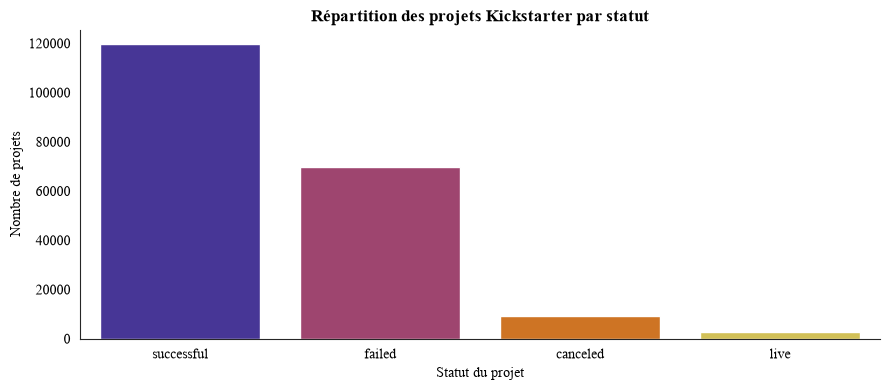

In [61]:
state_counts = kickstarter_df['state'].value_counts()
state_percent = kickstarter_df['state'].value_counts(normalize=True) * 100

print("--- Nombre de projets par statut ---")
print(state_counts)
print("\n--- Pourcentage par statut ---")
print(state_percent.round(2))

plt.figure(figsize=(9, 4))

sns.barplot(x=state_counts.index, y=state_counts.values, palette='CMRmap')

plt.title('Répartition des projets Kickstarter par statut')
plt.xlabel('Statut du projet')
plt.ylabel('Nombre de projets')

sns.despine()
plt.tight_layout()
plt.show()

### Corrélation entre les variables numériques

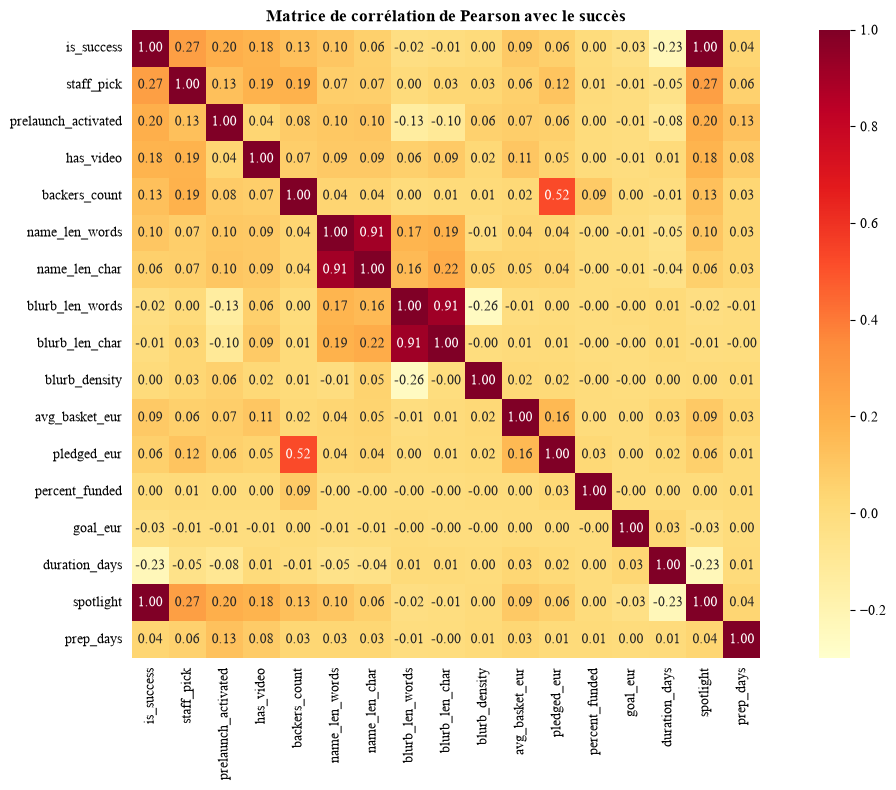

In [54]:
df_completed = kickstarter_df[kickstarter_df['state'].isin(['successful', 'failed', 'canceled'])].copy()

# Sélection des variables numériques à analyser
num_cols = [
    'is_success', 'staff_pick', 'prelaunch_activated', 'has_video', 
    'backers_count', 'name_len_words', 'name_len_char', 'blurb_len_words', 'blurb_len_char', 'blurb_density', 'avg_basket_eur', 
    'pledged_eur', 'percent_funded', 'goal_eur', 'duration_days', 'spotlight', 'prep_days'
]

# Matrice de corrélation
corr = df_completed[num_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr, 
    annot=True,          # Affiche les valeurs numériques dans chaque case
    fmt=".2f",           # Arrondit à 2 décimales
    cmap="YlOrRd",  
    vmin=-0.3, vmax=1.0, # Échelle de couleur
    square=True
)

plt.title("Matrice de corrélation de Pearson avec le succès")
plt.tight_layout()
plt.show()

D'après cette matrice, les 3 grands moteurs de succès sont :
* `staff_pick` : Preuve sociale et highlight
* `prelaunch_activated` : Une page de pré-lancement a été configurée.
* `has_video` : Une vidéo a été mise en ligne.

En revanche, on a un frein :
* `duration_days` : On peut supposer que plus une campagne est longue, moins il y a ce sentiment d'urgence.

Une autre corrélation à noter, hors-succès :
* Entre `backers_count` et `pledged_eur` : Plus on a de contributeurs, plus le montant récolté est élevé.

### Corrélation entre les variables qualitatives

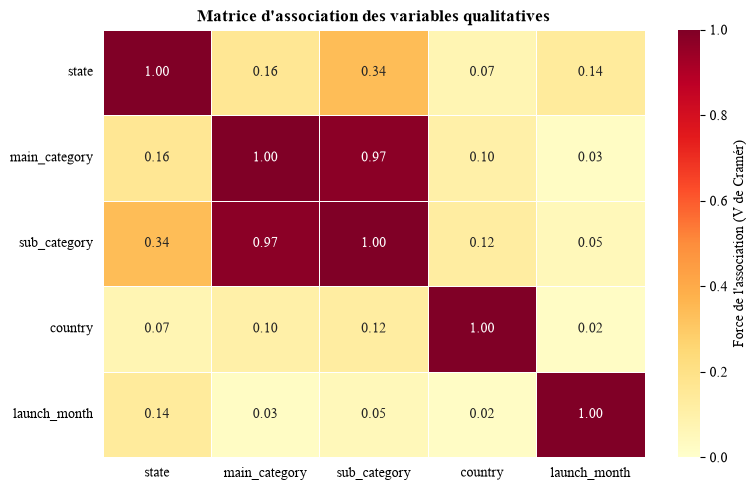

In [56]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcule le V de Cramér entre deux variables qualitatives."""
    # Création du tableau croisé (contingence)
    confusion_matrix = pd.crosstab(x, y)
    
    # Calcul du Chi-2
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    # Récupération du nombre total d'observations (n)
    n = confusion_matrix.sum().sum()
    
    # Récupération des dimensions (lignes et colonnes)
    r, c = confusion_matrix.shape
    
    # Application de la formule
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

colonnes_quali = ['state', 'main_category', 'sub_category', 'country', 'launch_month']

df_quali = kickstarter_df[colonnes_quali].dropna().copy()
cramer_matrix = pd.DataFrame(index=colonnes_quali, columns=colonnes_quali)

for col1 in colonnes_quali:
    for col2 in colonnes_quali:
        # On calcule le score pour chaque paire possible
        cramer_matrix.loc[col1, col2] = cramers_v(df_quali[col1], df_quali[col2])

cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cramer_matrix, 
    annot=True,            # Affiche les scores directement dans les cases
    fmt=".2f",             # Arrondit à 2 chiffres après la virgule
    cmap="YlOrRd",         # Palette de couleurs allant du jaune au rouge foncé
    vmin=0, vmax=1,        # L'échelle du V de Cramér est fixée entre 0 et 1
    linewidths=0.5,        # Lignes séparatrices pour la lisibilité
    cbar_kws={'label': 'Force de l\'association (V de Cramér)'}
)

plt.title("Matrice d'association des variables qualitatives")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

D'après cette matrice d'association, la sous-catégorie semble avoir plus d'influence sur le succès que la catégorie principale. En revanche, l'influence du mois de lancement et du pays de lancement est limitée.

## Finances

### Analyse des objectifs financiers
* Existe-t-il un "seuil critique" au-delà duquel le taux de succès chute drastiquement ?
* Comparaison de la médiane de goal_eur entre succès et échecs.

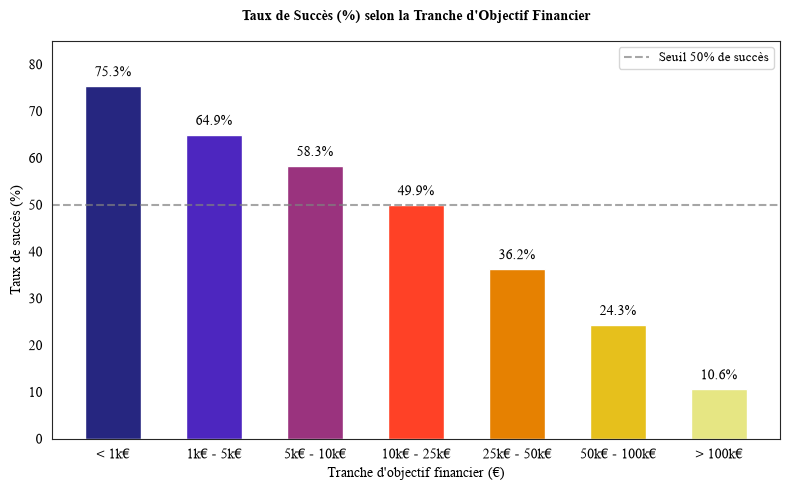

In [6]:
bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']

df_completed['goal_bin'] = pd.cut(df_completed['goal_eur'], bins=bins_goal, labels=labels_goal)


success_rate = df_completed.groupby('goal_bin', observed=False)['is_success'].mean() * 100


colors = sns.color_palette('CMRmap', len(success_rate))
plt.figure(figsize=(8, 5))

bars = plt.bar(
    success_rate.index, success_rate.values, color=colors, width=0.55
)

plt.title(
    "Taux de Succès (%) selon la Tranche d'Objectif Financier",
    fontsize=10,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Tranche d'objectif financier (€)")
plt.ylabel('Taux de succès (%)')

# Agrandir l'axe Y pour laisser de la place aux étiquettes
plt.ylim(0, 85)

# Ligne horizontale du seuil de 50%
plt.axhline(
    50, color='grey', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

# 5. Affichage des pourcentages bien au-dessus de chaque barre
for bar in bars:
  height = bar.get_height()
  plt.annotate(
      f'{height:.1f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height + 1.5),
      ha='center',
      va='bottom'
  )

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

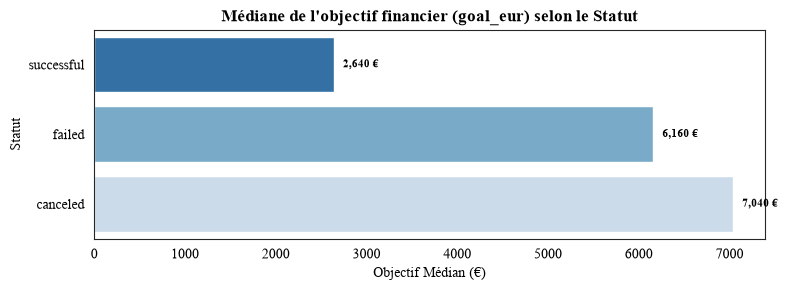

In [7]:
# Évaluer la médiane d'objectif financieier 
goal_medians = df_completed.groupby('state')['goal_eur'].median().reindex(['successful', 'failed', 'canceled'])

plt.figure(figsize=(8, 3))
ax = sns.barplot(x=goal_medians.values, y=goal_medians.index, palette='Blues_r', hue=goal_medians.index, legend=False)

plt.title("Médiane de l'objectif financier (goal_eur) selon le Statut")
plt.xlabel("Objectif Médian (€)")
plt.ylabel("Statut")

# Ajouter les montants exacts sur les barres
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f} €', (width + 100, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

D'après ces deux graphiques, on peut en conclure que plus l'objectif est élevé, moins la campagne a de chances de réussir.

* Les projets demandant moins de 1 000 € réussissent dans 3 cas sur 4 (75,3 %).
* À l'inverse, les projets ambitieux demandant plus de 100 000 € échouent à près de 90 % du temps.
* Il semble exister un seuil aux alentours des 25 000 €. En dessous de 25k€, le taux de succès reste égal ou supérieur à 50 %.
* Au-delà de 25k€, le taux de succès chute brutalement à 36,2 %, puis dégringole.

### Sur-performance et atteinte de l'objectif
* Distribution du taux de financement : détecter les outliers.

In [8]:
# Création d'une variable pour définir la sur-performance

import numpy as np

def categorize_performance(row):
    # Si le projet a échoué ou est annulé
    if row['state'] in ['failed', 'canceled']:
        return "Non financé <100%"
    # Si le projet est encore en cours
    elif row['state'] == 'live':
        return "En cours"
    # Si le projet est un succès, on le classe selon son percent_funded
    elif row['state'] == 'successful':
        pf = row['percent_funded']
        if pf < 105:
            return "Tout juste 100-105%"
        elif pf < 200:
            return "Modérée 105-200%"
        elif pf < 500:
            return "Solide 200-500%"
        elif pf < 1000:
            return "Très forte 500-1000%"
        else:
            return "Super-funded >1000%"
    return "Autre"

# Application de la fonction pour créer la nouvelle colonne
kickstarter_df['performance_tier'] = kickstarter_df.apply(categorize_performance, axis=1)

# Vérification du résultat
print(kickstarter_df['performance_tier'].value_counts().sort_index())

performance_tier
En cours                 2763
Modérée 105-200%        57093
Non financé <100%       79072
Solide 200-500%         17969
Super-funded >1000%     10264
Tout juste 100-105%     26519
Très forte 500-1000%     7751
Name: count, dtype: int64


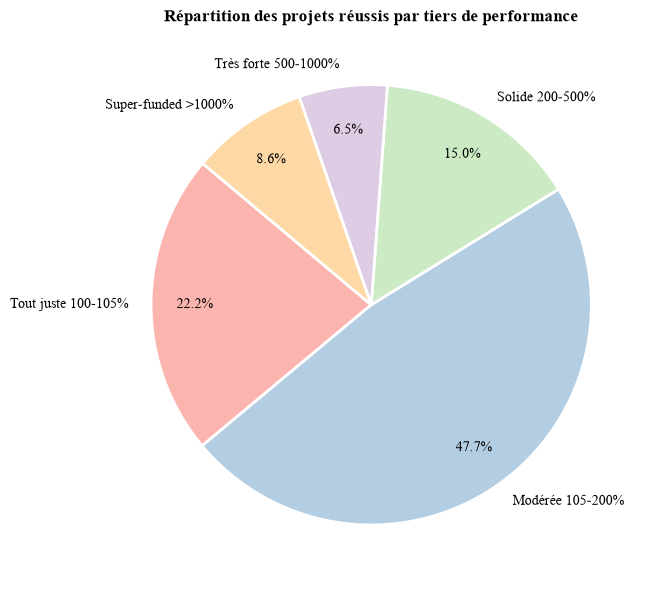

In [68]:
df_success = kickstarter_df[kickstarter_df['state'] == 'successful'].copy()

ordered_tiers = [
    "Tout juste 100-105%",
    "Modérée 105-200%",
    "Solide 200-500%",
    "Très forte 500-1000%",
    "Super-funded >1000%"
]

# 3. Calcul des proportions
tier_counts = df_success['performance_tier'].value_counts(normalize=True).reindex(ordered_tiers) * 100

# 4. Création de la figure
fig, ax = plt.subplots(figsize=(7, 6))

# Réutilisation de ta palette de couleurs
colors = sns.color_palette("Pastel1", len(tier_counts))

# 5. Tracé du camembert (pie chart)
wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=140, # Rotation pour que la plus grosse part soit bien placée
    colors=colors,
    pctdistance=0.8, # Écarte un peu les pourcentages du centre
    wedgeprops=dict(edgecolor='white', linewidth=2) # Liseré blanc pour détacher les parts
)

plt.title("Répartition des projets réussis par tiers de performance")

plt.tight_layout()
plt.show()

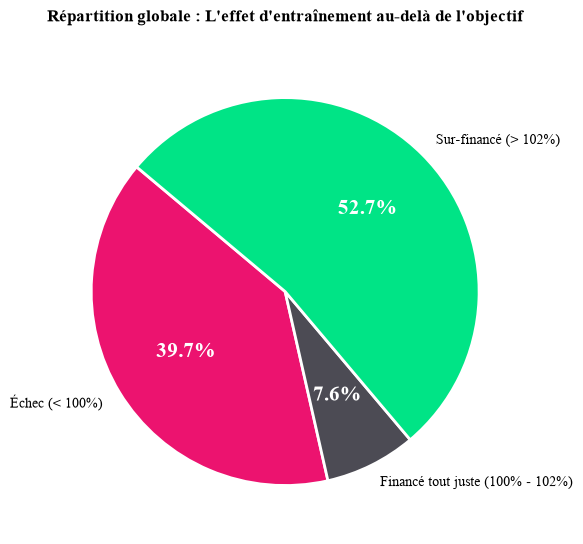

In [ ]:
def categorize_funding(val):
    if val < 100:
        return "Échec (< 100%)"
    elif 100 <= val <= 102:
        return "Financé tout juste (100% - 102%)"
    else:
        return "Sur-financé (> 102%)"

# Application aux données
df_completed['funding_category'] = df_completed['percent_funded'].apply(categorize_funding)
pie_data = df_completed['funding_category'].value_counts()

# Ordre d'affichage logique
order = ["Échec (< 100%)", "Financé tout juste (100% - 102%)", "Sur-financé (> 102%)"]
pie_data = pie_data.reindex(order)

# 2. Création du camembert
plt.figure(figsize=(6, 6))

# Assignation de tes couleurs strictes
custom_colors = ['#ec136f', '#4c4b54', "#00e486"]

wedges, texts, autotexts = plt.pie(
    pie_data, 
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140, # Rotation pour placer la plus grosse part en bas
    colors=custom_colors,
    wedgeprops=dict(edgecolor='#ffffff', linewidth=2) # Liseré blanc strict
)

# 3. Application de ta charte esthétique
plt.title("Répartition globale : L'effet d'entraînement au-delà de l'objectif", fontsize=12, fontweight='bold', color='#000000', pad=20)

# Personnalisation des textes (labels extérieurs et pourcentages intérieurs)
plt.setp(texts, fontsize=10, color='#000000') 
plt.setp(autotexts, fontsize=15, fontweight='bold', color='#ffffff')

plt.tight_layout()
plt.show()

In [10]:
super_funded_df = kickstarter_df[kickstarter_df['performance_tier'] == 'Super-funded >1000%'].copy()

# Tri
super_funded_df = super_funded_df.sort_values(by='percent_funded', ascending=False)

colonnes_super_funded = [
    'name', 
    'main_category', 
    'goal_eur', 
    'pledged_eur', 
    'percent_funded'
]

print("--- TOP 15 DES PROJETS SUPER-FUNDED ---")
display(super_funded_df[colonnes_super_funded].head(15))

--- TOP 15 DES PROJETS SUPER-FUNDED ---


,name,main_category,goal_eur,pledged_eur,percent_funded
13821,AdventureQuest Worlds: Infinity,Games,0.88,1891475.52,214940400.0
60782,Laurent Garnier: Off the Record,Film & Video,1.11,172172.13,15532039.0
24013,Voyage - New Album Campaign by The Longest Johns,Music,1.12,154291.45,13806700.0
182696,Re-covering with Friends,Music,0.88,60512.41,6876410.0
171087,The Swapper3D: NO MORE PURGE BLOCKS!,Technology,0.68,37602.54,5500829.0
66668,LET ME HOLD A DOLLA! | LARUSSELL GOES MAJORLY ...,Music,0.88,34692.24,3942300.0
22994,Tim Rose Visual Album: <3,Film & Video,0.88,25245.60,2868818.0
48727,CLOCKWRIGHT: Large-Scale Analogue Time Machines,Art,0.88,24277.64,2758823.0
51342,"Penny Arcade's Podcast, ""Downloadable Content""...",Publishing,8.80,202717.39,2303606.7
88148,"Multi-Purpose, All-Occasion Greeting Cards",Crafts,1.76,22132.26,1257515.0


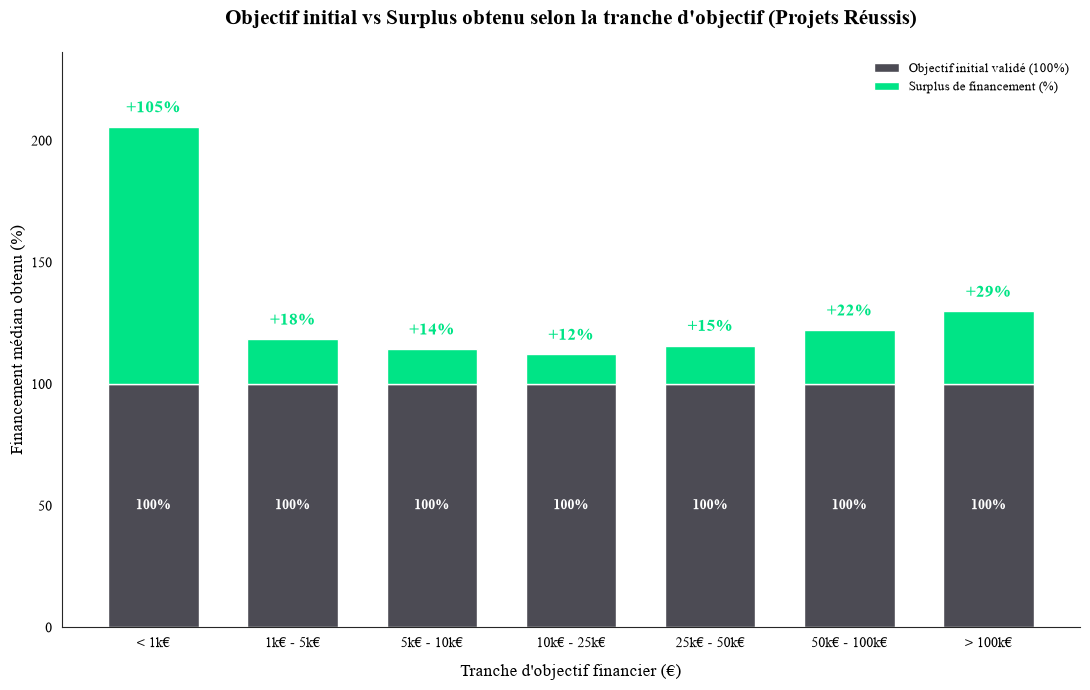

In [75]:
bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']
df_success['goal_bin'] = pd.cut(df_success['goal_eur'], bins=bins_goal, labels=labels_goal)

# 2. Agrégation : Financement médian obtenu
goal_perf = df_success.groupby('goal_bin', observed=True)['percent_funded'].median().reset_index()

# 3. Calculs pour le graphique empilé
# On fixe la base à 100 (puisque tous ces projets ont réussi, ils ont au moins atteint 100%)
goal_perf['base_100'] = 100
# Le surplus est la différence entre le financement total et les 100% initiaux
goal_perf['surplus_pct'] = goal_perf['percent_funded'] - 100

# 4. Création de la figure
plt.figure(figsize=(11, 7))

# --- Tracé de la base (L'objectif validé à 100%) ---
plt.bar(
    goal_perf['goal_bin'], 
    goal_perf['base_100'], 
    color='#4c4b54', # Gris/Bleu foncé pour le socle
    label="Objectif initial validé (100%)",
    width=0.65
)

# --- Tracé du surplus (Empilé au-dessus de la base) ---
plt.bar(
    goal_perf['goal_bin'], 
    goal_perf['surplus_pct'], 
    bottom=goal_perf['base_100'], # On empile sur les 100%
    color='#00e486',
    label="Surplus de financement (%)",
    width=0.65
)

# 5. Ajout des annotations de texte
for i in range(len(goal_perf)):
    base = goal_perf['base_100'].iloc[i]
    surplus = goal_perf['surplus_pct'].iloc[i]
    total = goal_perf['percent_funded'].iloc[i]
    
    # Texte dans la barre de base (le socle)
    plt.annotate(
        "100%",
        (i, base / 2), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    # Texte au-dessus de la barre de surplus : Le +X%
    if surplus > 0:
        plt.annotate(
            f"+{int(surplus)}%",
            (i, total),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color="#00e486"
        )

# 6. Personnalisation esthétique
plt.title("Objectif initial vs Surplus obtenu selon la tranche d'objectif (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Tranche d'objectif financier (€)", fontsize=12, labelpad=10)
plt.ylabel("Financement médian obtenu (%)", fontsize=12)

# On ajuste l'axe Y pour laisser de la place aux annotations
plt.ylim(0, goal_perf['percent_funded'].max() * 1.15)

sns.despine()
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

* Les projets fixant un objectif de moins de 1000 € sur-performent le plus. Fixer un objectif plancher très bas peut être une technique d'amorçage intéressante. Cela permet de valider le financement, de voir son projet en "Spotlight" et d'enclencher la preuve sociale.

* Sur les tranches intermédiaires, le taux de performance se stabilise entre 112 et 122%.

* Paradoxalement, les projets très ambitieux qui parviennent à réussir affichent une remontée de leur performance à 129%. Même si le taux de succès s'effondre sur ces gros montants, si un porteur de projet parvient à le réussir, cela constitue une forte preuve sociale.


### Analyse des fonds collectés
* Volume total récolté sur la plateforme et médiane des montants levés.

In [12]:
volume_total = kickstarter_df['pledged_eur'].sum()
mediane_globale = kickstarter_df['pledged_eur'].median()
moyenne_globale = kickstarter_df['pledged_eur'].mean()

volume_success = df_success['pledged_eur'].sum()
mediane_success = df_success['pledged_eur'].median()
moyenne_success = df_success['pledged_eur'].mean()

print(f"Volume total récolté sur la plateforme : {volume_total:,.0f} €")
print(f"Médiane globale des montants levés : {mediane_globale:,.0f} €")
print(f"Moyenne globale des montants levés : {moyenne_globale:,.0f} €")
print("------------------------------------------------")
print(f"Volume récolté (uniquement projets réussis) : {volume_success:,.0f} €")
print(f"Médiane des levées (uniquement projets réussis) : {mediane_success:,.0f} €")
print(f"Moyenne des levées (uniquement projets réussis) : {moyenne_success:,.0f} €")

Volume total récolté sur la plateforme : 2,947,266,707 €
Médiane globale des montants levés : 1,617 €
Moyenne globale des montants levés : 14,632 €
------------------------------------------------
Volume récolté (uniquement projets réussis) : 2,800,687,212 €
Médiane des levées (uniquement projets réussis) : 4,452 €
Moyenne des levées (uniquement projets réussis) : 23,418 €


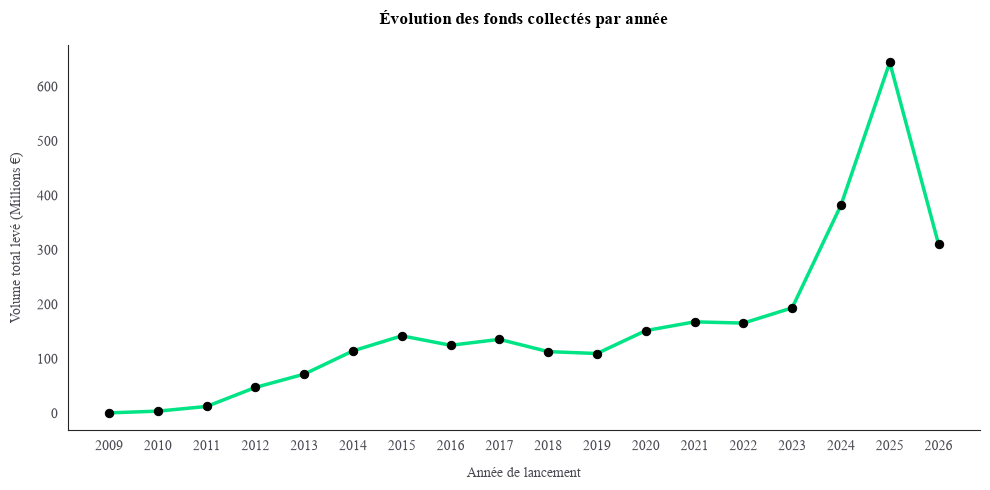

In [65]:

gmv_per_year = df_completed.groupby('launch_year')['pledged_eur'].sum().reset_index()

gmv_per_year['gmv_millions'] = gmv_per_year['pledged_eur'] / 1_000_000


plt.figure(figsize=(10, 5))

sns.lineplot(
    data=gmv_per_year, 
    x='launch_year', 
    y='gmv_millions', 
    color='#00e486', 
    linewidth=2.5, 
    marker='o',
    markersize=6,
    markerfacecolor='#000000', 
    markeredgecolor='#000000'
)

# 3. Application de ta charte graphique stricte
plt.title('Évolution des fonds collectés par année', fontsize=12, fontweight='bold', color='#000000', pad=15)
plt.xlabel('Année de lancement', fontsize=10, color='#4c4b54', labelpad=10)
# Mise à jour du label de l'axe Y pour refléter l'unité
plt.ylabel('Volume total levé (Millions €)', fontsize=10, color='#4c4b54', labelpad=10)

plt.xticks(gmv_per_year['launch_year'], fontsize=10, color='#4c4b54') 
plt.yticks(fontsize=10, color='#4c4b54')

sns.despine()
plt.tight_layout()
plt.show()

On constate une grande différence entre médiane et moyenne, ce qui indique de très grandes disparités de levées de fonds. On va donc se concentrer sur la médiane qui se rapproche de la réalité du plus grand nombre de projets.

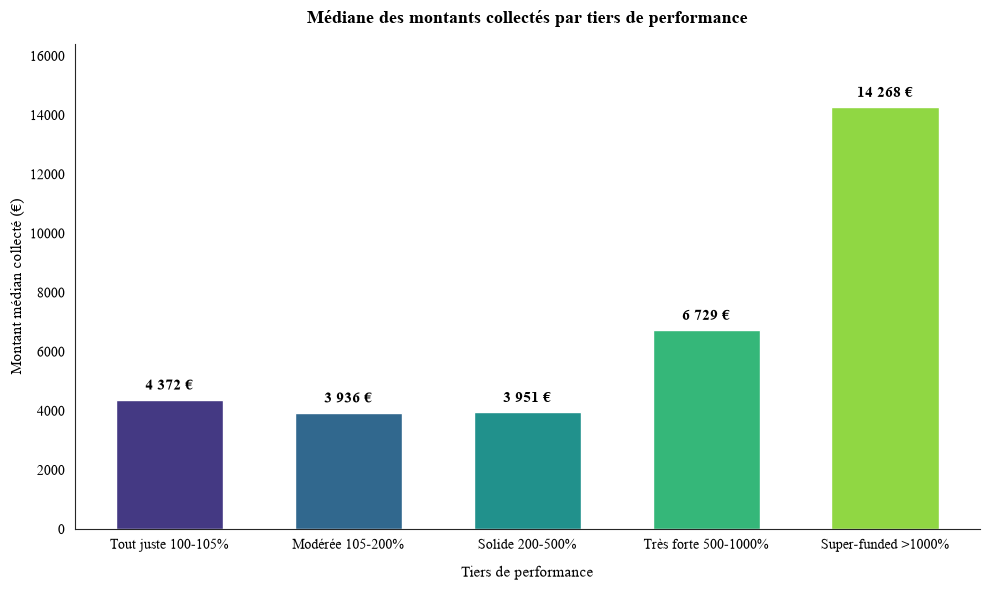

In [76]:
median_by_tier = kickstarter_df.groupby('performance_tier')['pledged_eur'].median().reindex(ordered_tiers)


plt.figure(figsize=(10, 6)) # Légèrement élargi pour donner de l'espace aux labels
colors = sns.color_palette("viridis", len(median_by_tier))

bars = plt.bar(median_by_tier.index, median_by_tier.values, color=colors, width=0.6)


plt.title("Médiane des montants collectés par tiers de performance", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tiers de performance", fontsize=11, labelpad=10)
plt.ylabel("Montant médian collecté (€)", fontsize=11)

plt.ylim(0, median_by_tier.max() * 1.15)


for bar in bars:
    height = bar.get_height()
    if pd.notnull(height): # Sécurité au cas où une catégorie serait vide
        plt.annotate(
            f'{height:,.0f} €'.replace(',', ' '), # Remplacement de la virgule par un espace pour les milliers
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5), 
            textcoords="offset points",
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

sns.despine()
plt.tight_layout()
plt.show()

## Temporalité

### Évolution annuelle
* Tendance de croissance du nombre de projets et du volume financier au fil des ans.
* Évolution du taux de succès au fil du temps.

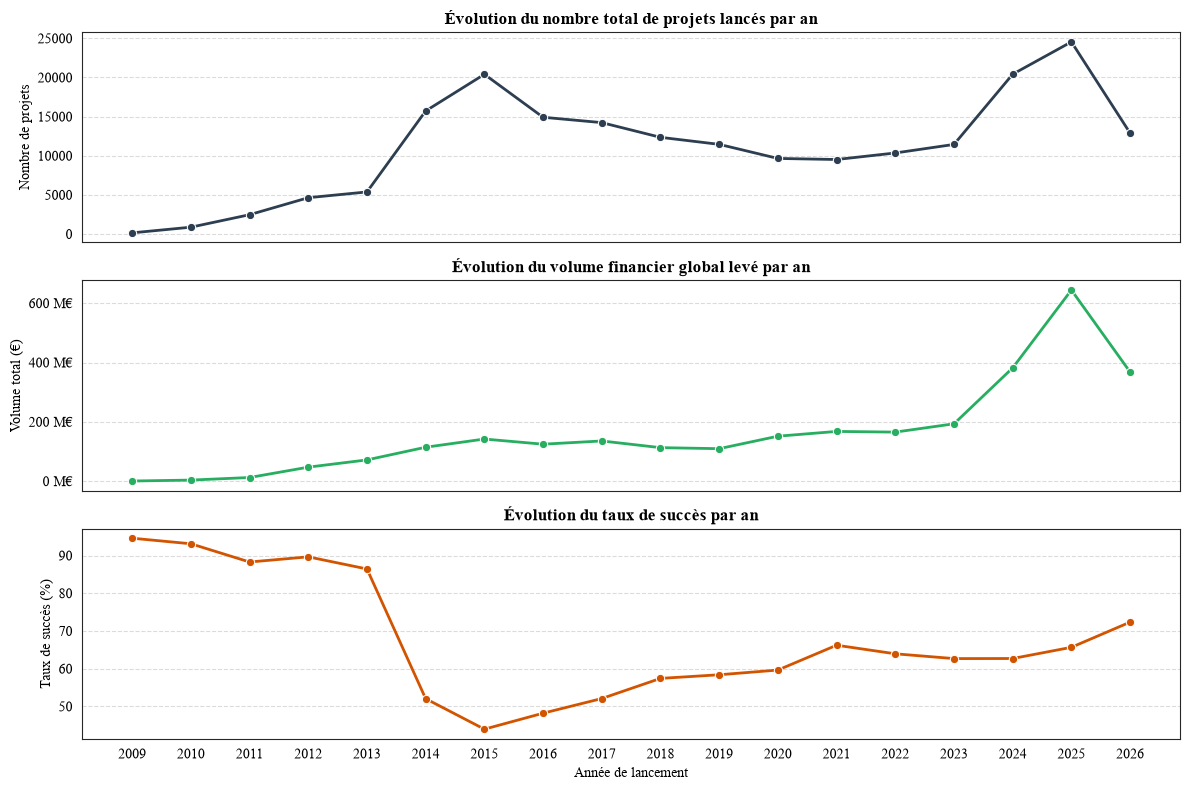

In [14]:
# Total projet par année et volume levé par année
yearly_global = kickstarter_df.groupby('launch_year').agg(
    num_projects=('name', 'count'),      # Nombre total de projets lancés
    total_volume=('pledged_eur', 'sum')  # Volume financier total levé
).reset_index()

# Taux de succès par année
yearly_success = df_completed.groupby('launch_year').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

# Fusion des statistiques
yearly_stats = pd.merge(yearly_global, yearly_success, on='launch_year', how='left')

# Graphiques
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Nombre total de projets
sns.lineplot(data=yearly_stats, x='launch_year', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par an", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Volume financier global
sns.lineplot(data=yearly_stats, x='launch_year', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par an", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
# Formatage en millions d'euros
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

# Graphique 3 : Taux de succès
sns.lineplot(data=yearly_stats, x='launch_year', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par an", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Année de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Affichage des années sans décimales
axes[2].set_xticks(yearly_stats['launch_year'])

plt.tight_layout()
plt.show()

En regardant ces trois graphiques, on voit une correction assez nette du taux de réussite entre 2013 et 2015. Le marché de Kickstarter a gagné en maturité. Depuis 2023, le volume financier levé a connu une nette hausse qui semble corrélée à l'augmentation du nombre de projets lancés ; cela dit, le taux de succès reste plutôt stable, avec une tendance haussière assez timide depuis 2024.

L'année 2026 n'est pas encore terminée donc il est impossible d'en savoir plus, mais la tendance est haussière ce qui devrait encourager les entrepreneurs et les start-ups à tester leurs idées sur la plateforme.

### Saisonnalité
* Y a-t-il un "meilleur mois" pour lancer un projet (taux de succès + volume) ?

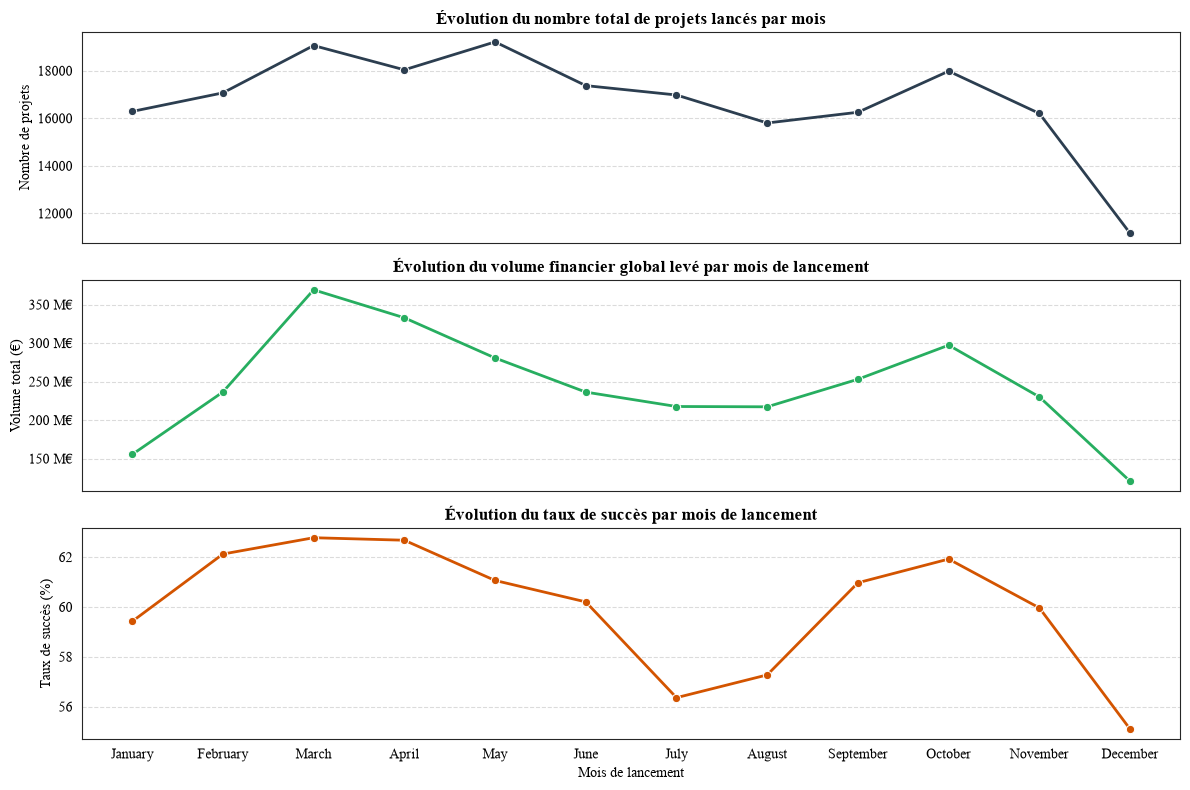

launch_month
January      16288
February     17070
March        19060
April        18039
May          19213
June         17375
July         16980
August       15803
September    16254
October      17983
November     16204
December     11162
Name: count, dtype: int64


In [77]:
# Ordre chronologique exact
ordre_mois = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']

# Forcer cet ordre logique
kickstarter_df['launch_month'] = pd.Categorical(kickstarter_df['launch_month'], categories=ordre_mois, ordered=True)

monthly_global = kickstarter_df.groupby('launch_month', observed=False).agg(
    num_projects=('name', 'count'),      
    total_volume=('pledged_eur', 'sum')  
).reset_index()

monthly_success = df_completed.groupby('launch_month', observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

monthly_stats = pd.merge(monthly_global, monthly_success, on='launch_month', how='left')

# Graphiques
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Nombre total de projets par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par mois", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Volume financier global par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par mois de lancement", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

# Graphique 3 : Taux de succès par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par mois de lancement", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Mois de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(kickstarter_df['launch_month'].value_counts().sort_index())

A priori, lancer sa campagne pendant les vacances de Noël (Décembre - Janvier) et pendant les vacances d'été (Juillet - Août) n'est pas recommandé car le taux de succès et le volume levé chute durant ces périodes. Il est important de noter que le nombre de projets lancés durant ces périodes chute également (sauf en Juillet) donc à prendre avec un grain de sel, mais si on ne souhaite vraiment pas prendre de risque, il vaut mieux éviter ces périodes.

### Durée de la campagne
* Est-ce que les campagnes plus courtes réussissent mieux que les campagnes longues ?

In [16]:
print("====== Statistiques de la durée des campagnes (en jours) ======")
print(kickstarter_df['duration_days'].describe())

====== Statistiques de la durée des campagnes (en jours) ======
count    201431.000000
mean         33.089490
std          12.886899
min           1.000000
25%          29.000000
50%          30.000000
75%          36.000000
max         120.000000
Name: duration_days, dtype: float64


/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/4277111667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=success_rate_duration.index, y=success_rate_duration.values, palette='BuPu')


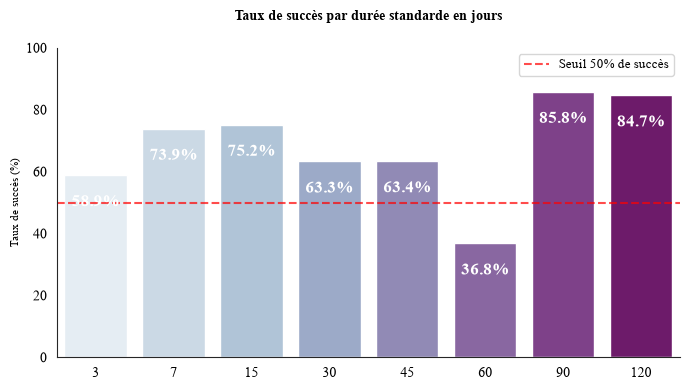

In [17]:
# Catégories de durées et labels propres (sans notation mathématique)
bins_duration = [0, 3, 7, 15, 30, 45, 60, 75, 120]
labels_duration = ['3', '7', '15', '30', '45', '60', '90', '120']

df_completed['duration_category'] = pd.cut(df_completed['duration_days'], bins=bins_duration, labels=labels_duration)

# Calcul du taux de succès par catégorie de durée
success_rate_duration = df_completed.groupby('duration_category', observed=False)['is_success'].mean() * 100

# Barplot
plt.figure(figsize=(7, 4))

bars = sns.barplot(x=success_rate_duration.index, y=success_rate_duration.values, palette='BuPu')

plt.title("Taux de succès par durée standarde en jours", fontsize=10, fontweight='bold', pad=20)
plt.ylabel("Taux de succès (%)", fontsize=8)
plt.xlabel("") # Pas besoin de titre pour l'axe X, les labels suffisent
plt.ylim(0, 100) # Échelle fixe de 0 à 100 pour ne pas fausser la perception

# Ligne horizontale du seuil de 50%
plt.axhline(
    50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

for bar in bars.patches:
    plt.annotate(
        f'{bar.get_height():.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, -25), # Place le texte à l'intérieur de la barre
        textcoords="offset points",
        ha='center', va='bottom', 
        fontsize=12, fontweight='bold', color='white'
    )

sns.despine()

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

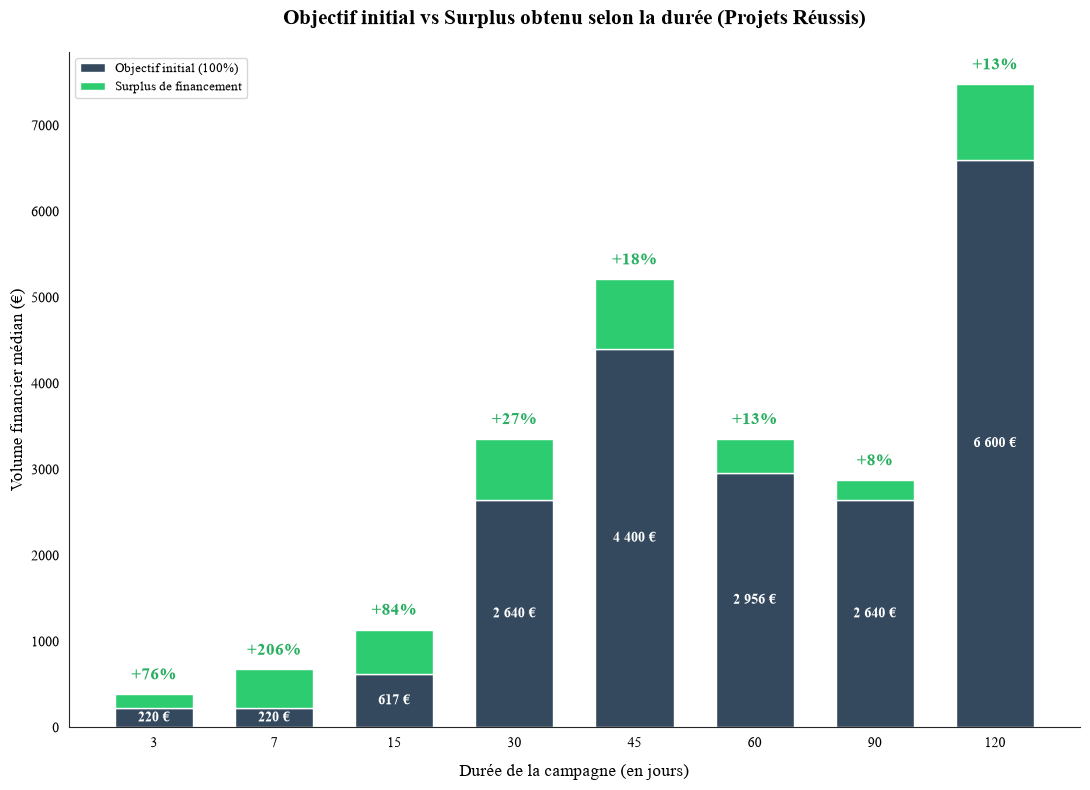

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des données (Projets réussis uniquement)
df_success = kickstarter_df[kickstarter_df['state'] == 'successful'].copy()

bins_duration = [0, 3, 7, 15, 30, 45, 60, 90, 120]
labels_duration = ['3', '7', '15', '30', '45', '60', '90', '120']
df_success['duration_category'] = pd.cut(df_success['duration_days'], bins=bins_duration, labels=labels_duration)

# 2. Agrégation : Objectif médian et Pourcentage de financement médian
agg_success = df_success.groupby('duration_category', observed=False).agg(
    median_goal=('goal_eur', 'median'),
    median_funded=('percent_funded', 'median')
).reset_index()

# 3. Calculs pour le graphique empilé
# Le surplus en % (Financement total - 100% de l'objectif)
agg_success['surplus_pct'] = agg_success['median_funded'] - 100
# Conversion du surplus % en euros pour définir la hauteur de la barre supérieure
agg_success['surplus_eur'] = agg_success['median_goal'] * (agg_success['surplus_pct'] / 100)

# 4. Création de la figure
plt.figure(figsize=(11, 8))

# --- Tracé de la base (L'objectif à 100%) ---
plt.bar(
    agg_success['duration_category'], 
    agg_success['median_goal'], 
    color='#34495e', # Gris/Bleu foncé
    label="Objectif initial (100%)",
    width=0.65
)

# --- Tracé du surplus (Empilé au-dessus de la base) ---
plt.bar(
    agg_success['duration_category'], 
    agg_success['surplus_eur'], 
    bottom=agg_success['median_goal'], # C'est ici qu'on empile !
    color='#2ecc71', # Vert pour symboliser la surperformance
    label="Surplus de financement",
    width=0.65
)

# 5. Ajout des annotations de texte
for i in range(len(agg_success)):
    goal = agg_success['median_goal'].iloc[i]
    surplus_eur = agg_success['surplus_eur'].iloc[i]
    surplus_pct = agg_success['surplus_pct'].iloc[i]
    total_height = goal + surplus_eur
    
    if pd.notnull(goal) and goal > 0:
        # Texte dans la barre de base : Le montant en euros
        plt.annotate(
            f"{int(goal):,} €".replace(',', ' '),
            (i, goal / 2), # Centré verticalement dans la barre du bas
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='white'
        )
        
        # Texte au-dessus de la barre de surplus : Le +X%
        plt.annotate(
            f"+{int(surplus_pct)}%",
            (i, total_height),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#27ae60'
        )

# 6. Personnalisation esthétique
plt.title("Objectif initial vs Surplus obtenu selon la durée (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Durée de la campagne (en jours)", fontsize=12, labelpad=10)
plt.ylabel("Volume financier médian (€)", fontsize=12)

sns.despine()
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Quelle durée recommandée pour chaque tranche d'objectif ?

--- RECOMMANDATION DE DURÉE PAR OBJECTIF FINANCIER ---
        goal_bin duration_bin  success_rate
4          < 1k€        > 60j     88.888889
9      1k€ - 5k€        > 60j     89.417989
14    5k€ - 10k€        > 60j     78.947368
19   10k€ - 25k€        > 60j     84.375000
22   25k€ - 50k€     30 - 45j     46.221386
27  50k€ - 100k€     30 - 45j     36.963190
32       > 100k€     30 - 45j     19.193154


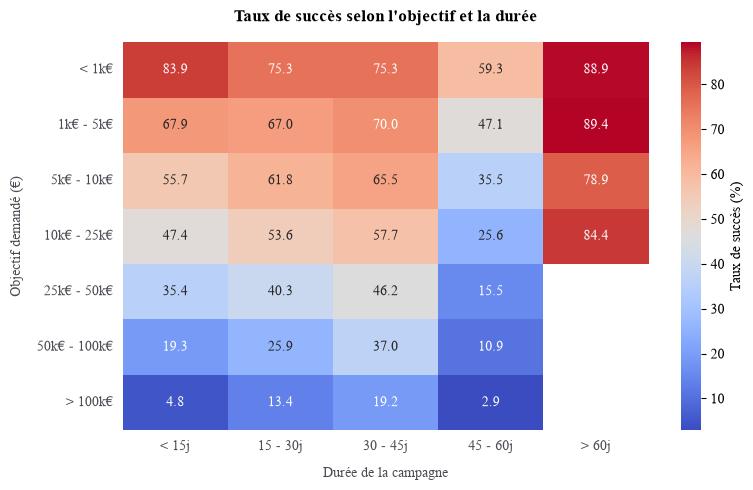

In [49]:

bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']
df_completed['goal_bin'] = pd.cut(df_completed['goal_eur'], bins=bins_goal, labels=labels_goal)

# Tranches de durée (simplifiées pour la recommandation)
bins_duration = [0, 15, 30, 45, 60, np.inf]
labels_duration = ['< 15j', '15 - 30j', '30 - 45j', '45 - 60j', '> 60j']
df_completed['duration_bin'] = pd.cut(df_completed['duration_days'], bins=bins_duration, labels=labels_duration)

# ==========================================
# 2. CALCUL DE LA MATRICE
# ==========================================
# On calcule le taux de succès et le volume pour chaque croisement Objectif/Durée
matrix_stats = df_completed.groupby(['goal_bin', 'duration_bin'], observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

# Règle de sécurité : On exclut les cas avec moins de 30 projets pour ne pas recommander sur du bruit statistique
matrix_stats = matrix_stats[matrix_stats['volume'] >= 30]

# --- EXTRACTION DE LA RECOMMANDATION ---
# On trie pour mettre le meilleur taux de succès en premier, puis on garde le Top 1 par tranche d'objectif
optimal_duration = matrix_stats.sort_values(['goal_bin', 'success_rate'], ascending=[True, False])
optimal_duration = optimal_duration.groupby('goal_bin', observed=False).head(1)

print("--- RECOMMANDATION DE DURÉE PAR OBJECTIF FINANCIER ---")
print(optimal_duration[['goal_bin', 'duration_bin', 'success_rate']])

# ==========================================
# 3. VISUALISATION (Heatmap)
# ==========================================
# On pivote les données pour créer la grille de la carte de chaleur
heatmap_data = matrix_stats.pivot(index='goal_bin', columns='duration_bin', values='success_rate')

plt.figure(figsize=(8, 5))

# Création de la Heatmap avec ta palette viridis
sns.heatmap(
    heatmap_data, 
    annot=True,          # Affiche les chiffres dans les cases
    fmt=".1f",           # 1 chiffre après la virgule
    cmap="coolwarm",      # Ta palette autorisée
    cbar_kws={'label': 'Taux de succès (%)'}
)

# Application de ta charte graphique stricte (si rcParams non actif)
plt.title("Taux de succès selon l'objectif et la durée", fontsize=12, fontweight='bold', color='#000000', pad=15)
plt.xlabel("Durée de la campagne", fontsize=10, color='#4c4b54', labelpad=10)
plt.ylabel("Objectif demandé (€)", fontsize=10, color='#4c4b54', labelpad=10)

plt.xticks(fontsize=10, color='#4c4b54')
plt.yticks(fontsize=10, color='#4c4b54')

plt.tight_layout()
plt.show()

### Phase de préparation
* Prendre du temps pour préparer sa page augmente-t-il les chances de succès ?

In [19]:
print("====== Statistiques de la durée de préparation (en jours) ======")
print(kickstarter_df['prep_days'].describe())

====== Statistiques de la durée de préparation (en jours) ======
count    201431.000000
mean         55.296404
std         161.537544
min           0.000000
25%           3.000000
50%          14.000000
75%          44.000000
max        5061.000000
Name: prep_days, dtype: float64


Ces statistiques ont mis en lumière la présence d'outliers. 5061 jours c'est 14 ans de préparation pour un projet. On peut considérer que ces outliers sont des comptes qui ont créé un brouillon de projet, l'ont abandonné et puis l'ont finalement lancé des années plus tard. Il ne s'agit donc pas d'un vrai temps de préparation.

Pour analyser au mieux, il faut créer des catégories de durée.

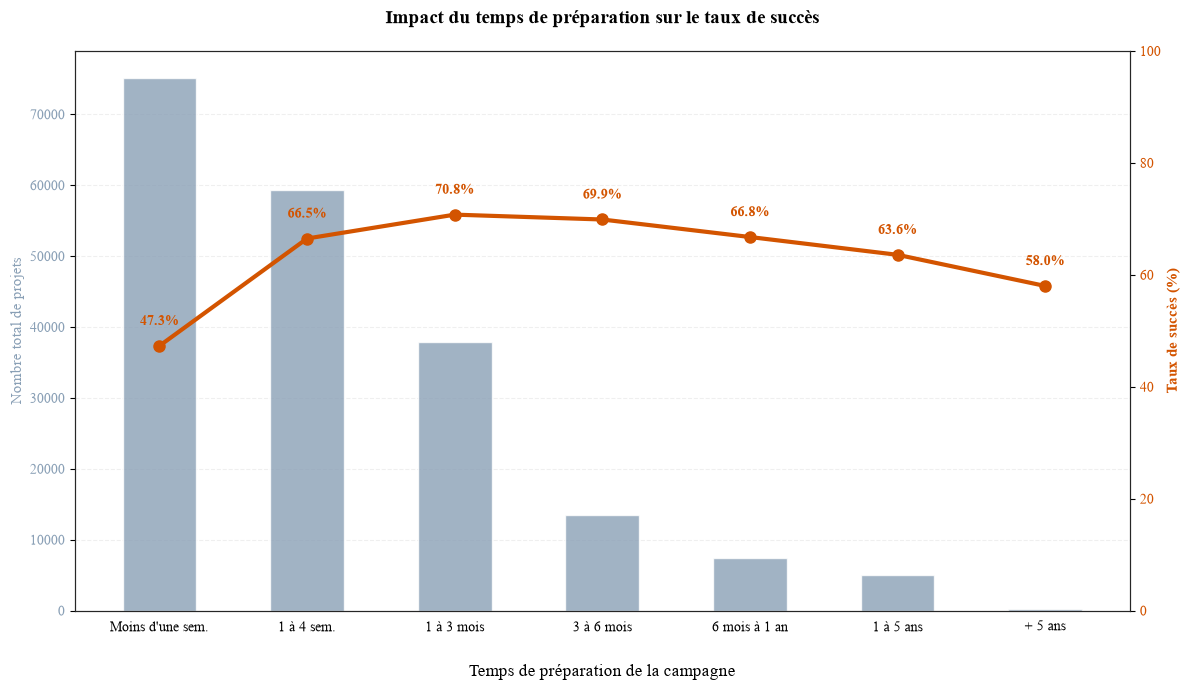

In [20]:
bins = [-1, 7, 30, 90, 180, 365, 1825, float('inf')]
labels = [
    "Moins d'une sem.\n", 
    "1 à 4 sem.\n", 
    "1 à 3 mois\n", 
    "3 à 6 mois\n",
    "6 mois à 1 an\n",
    "1 à 5 ans\n", 
    "+ 5 ans"
]
df_completed['prep_tier'] = pd.cut(df_completed['prep_days'], bins=bins, labels=labels)

prep_stats = df_completed.groupby('prep_tier', observed=False).agg(
    num_projects=('is_success', 'count'),
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar plot pour le volume de projets
color_bar = "#8aa0b6"
bars = ax1.bar(prep_stats['prep_tier'], prep_stats['num_projects'], color=color_bar, alpha=0.8, width=0.5)
ax1.set_xlabel('Temps de préparation de la campagne', fontsize=12, labelpad=10)
ax1.set_ylabel('Nombre total de projets', color=color_bar, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Line plot pour le taux de succès
ax2 = ax1.twinx()
color_line = '#d35400'
ax2.plot(prep_stats['prep_tier'], prep_stats['success_rate'], color=color_line, marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Taux de succès (%)', color=color_line, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 100)

# Ajout des pourcentages exacts sur la courbe
for i, txt in enumerate(prep_stats['success_rate']):
    if not pd.isna(txt):
        ax2.annotate(f"{txt:.1f}%", 
                     (i, txt), 
                     textcoords="offset points", 
                     xytext=(0, 15), 
                     ha='center', 
                     color=color_line, 
                     fontweight='bold')

plt.title("Impact du temps de préparation sur le taux de succès", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

En regardant ce graphique, on peut voir qu'il vaut mieux ne pas se précipiter pour lancer sa campagne. Les projets qui ont été préparés en moins d'une semaine ont moins d'une chance sur deux de réussir. Le pourcentage de chances de réussir augmente si la préparation prend entre 1 et 4 semaines, atteignant son sweet spot entre 1 et 3 mois. 

## Communauté

### Taille de communauté
* Combien de personnes soutiennent un projet en moyenne selon le statut ?

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3722676618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3722676618.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  barplot.set_xticklabels(['Succès', 'Échec', 'Annulé'], fontsize=11)


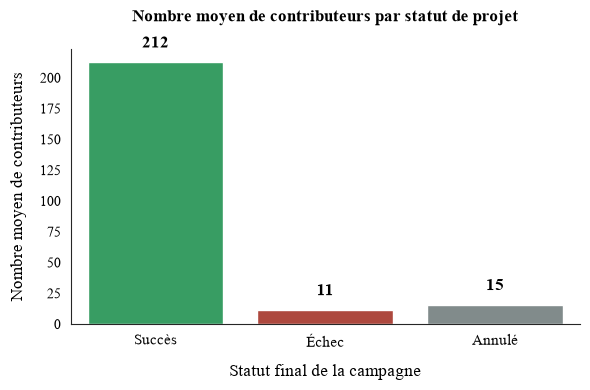

In [21]:

plt.figure(figsize=(6, 4))

barplot = sns.barplot(
    data=df_completed, 
    x='state', 
    y='backers_count', 
    order=['successful', 'failed', 'canceled'], # On force un ordre logique
    palette=['#27ae60', '#c0392b', '#7f8c8d'],   # Vert (succès), Rouge (échec), Gris (annulé)
    errorbar=None
)

plt.title("Nombre moyen de contributeurs par statut de projet", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Statut final de la campagne", fontsize=12, labelpad=10)
plt.ylabel("Nombre moyen de contributeurs", fontsize=12, labelpad=10)

barplot.set_xticklabels(['Succès', 'Échec', 'Annulé'], fontsize=11)

for p in barplot.patches:
    barplot.annotate(
        format(int(p.get_height()), ','), # Ajoute un séparateur de milliers si besoin
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=12, fontweight='bold'
    )

sns.despine()

plt.tight_layout()
plt.show()

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/423991716.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


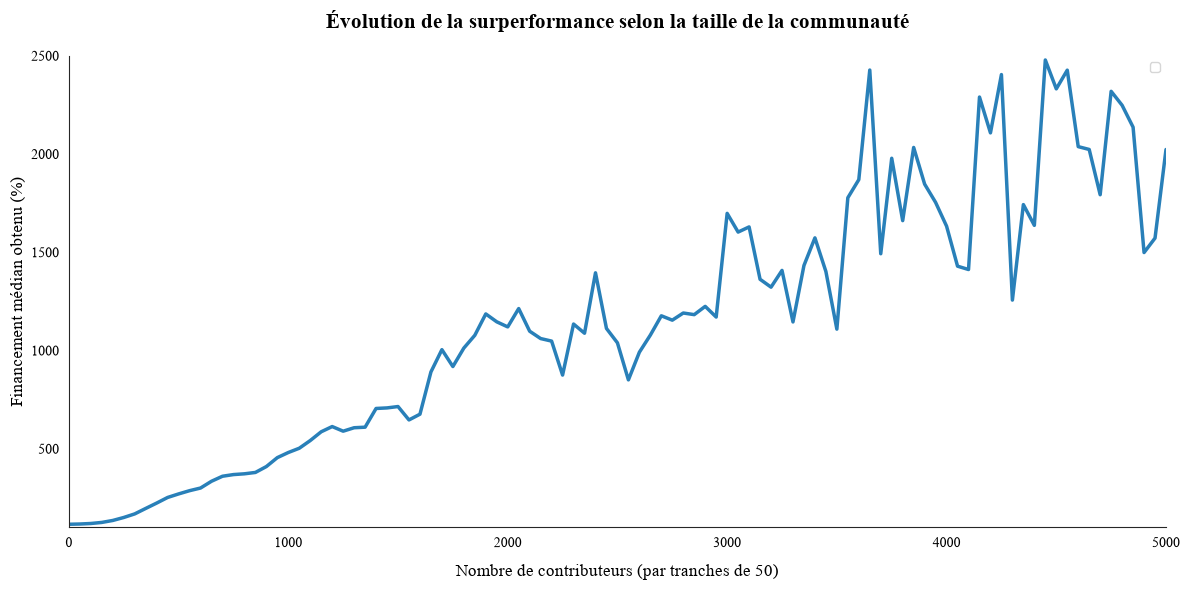

In [22]:
# Regrouper par tranches de 50 backers
df_success['backers_group'] = (df_success['backers_count'] // 50) * 50

# Médiane par tranche
trend_df = df_success.groupby('backers_group').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

trend_df = trend_df[trend_df['backers_group'] <= 5000]


trend_df['smoothed'] = trend_df['median_funded'].rolling(window=3, min_periods=1).mean()


plt.figure(figsize=(12, 6))

sns.lineplot(
    data=trend_df, 
    x='backers_group', 
    y='smoothed', 
    color='#2980b9', 
    linewidth=2.5
)

plt.title("Évolution de la surperformance selon la taille de la communauté", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Nombre de contributeurs (par tranches de 50)", fontsize=12, labelpad=10)
plt.ylabel("Financement médian obtenu (%)", fontsize=12)

plt.ylim(100, 2500)
plt.xlim(0, 5000)

plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

Le regroupement par paquet de 50 backers permet d'avoir une courbe de tendance plus lisible, car on calcule la médiane de performance par paquet de 50.

La courbe nous montre que la taille de la communauté est corrélée à la sur-performance d'un projet.

### Panier moyen
* Les projets financés s'appuient-ils sur beaucoup de petits donateurs ou sur quelques gros contributeurs ?

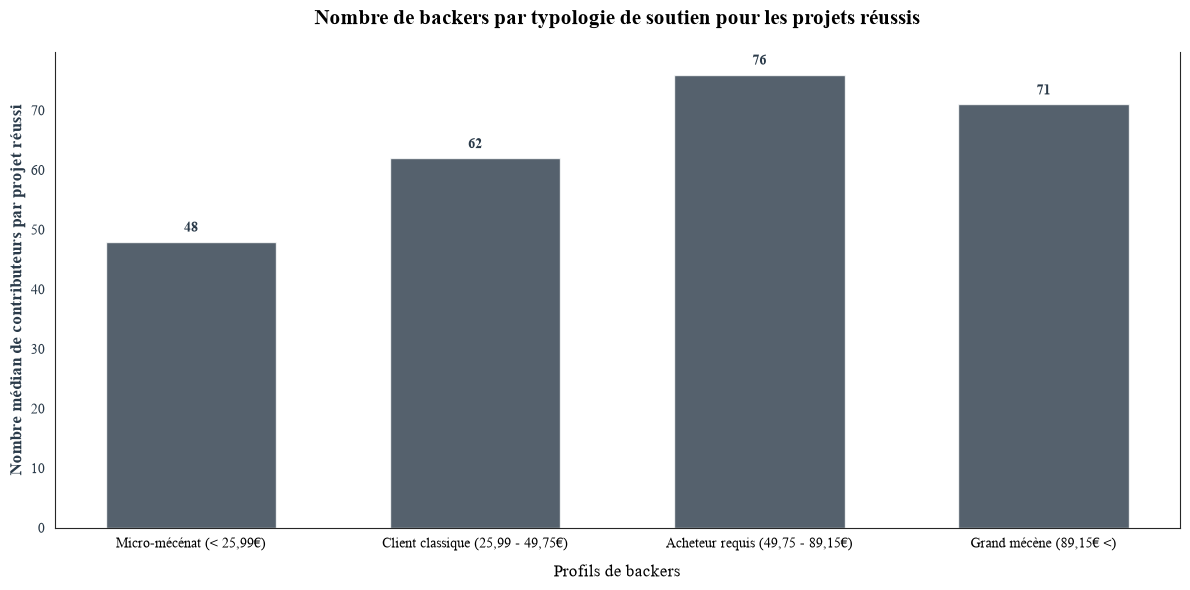

In [23]:
df_success = kickstarter_df[
    (kickstarter_df['state'] == 'successful') & 
    (kickstarter_df['backer_profile_qcut'] != 'Aucun soutien (0€)')
].copy()

stats_profile = df_success.groupby('backer_profile_qcut', observed=True).agg(
    median_backers=('backers_count', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

ordre_qcut = [
    'Micro-mécénat (< 25,99€)', 
    'Client classique (25,99 - 49,75€)', 
    'Acheteur requis (49,75 - 89,15€)', 
    'Grand mécène (89,15€ <)'
]
stats_profile['backer_profile_qcut'] = pd.Categorical(stats_profile['backer_profile_qcut'], categories=ordre_qcut, ordered=True)
stats_profile = stats_profile.sort_values('backer_profile_qcut')

fig, ax1 = plt.subplots(figsize=(12, 6))

color_backers = "#2a3a49"
bars = ax1.bar(stats_profile['backer_profile_qcut'], stats_profile['median_backers'], color=color_backers, alpha=0.8, width=0.6)
ax1.set_ylabel("Nombre médian de contributeurs par projet réussi", color=color_backers, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_backers)
ax1.set_xlabel("Profils de backers", fontsize=12, labelpad=10)

for bar in bars.patches:
    ax1.annotate(f"{int(bar.get_height())}",
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                 color=color_backers, fontweight='bold')

plt.title("Nombre de backers par typologie de soutien pour les projets réussis", fontsize=15, fontweight='bold', pad=20)
sns.despine(right=False)
plt.tight_layout()
plt.show()

In [24]:
valid_pledges = kickstarter_df[kickstarter_df['avg_basket_eur'] > 0]['avg_basket_eur']

# Seuils des quartiles du panier moyen
quartiles = valid_pledges.quantile([0, 0.25, 0.50, 0.75, 1.0])
print("Pour rappel, voici les seuils de panier moyen par type de backers :")
print(f"Min (0%)    : {quartiles[0.00]:.2f} €")
print(f"Q1  (25%)   : {quartiles[0.25]:.2f} €  -> Micro-mécénat")
print(f"Q2  (50%)   : {quartiles[0.50]:.2f} €  -> Client standard")
print(f"Q3  (75%)   : {quartiles[0.75]:.2f} €  -> Acheteur requis")
print(f"Max (100%)  : {quartiles[1.00]:.2f} €  -> Grand mécène")

Pour rappel, voici les seuils de panier moyen par type de backers :
Min (0%)    : 0.40 €
Q1  (25%)   : 25.99 €  -> Micro-mécénat
Q2  (50%)   : 49.75 €  -> Client standard
Q3  (75%)   : 89.15 €  -> Acheteur requis
Max (100%)  : 9651.02 €  -> Grand mécène


In [25]:
print("==== Médiane globale de backers nécessaires pour réussir ====")
print(df_success['backers_count'].median())

print("==== Moyenne globale de backers nécessaires pour réussir ====")
print(df_success['backers_count'].mean())

==== Médiane globale de backers nécessaires pour réussir ====
67.0
==== Moyenne globale de backers nécessaires pour réussir ====
212.6618030703368


Les projets qui se reposent sur des micro-mécènes n'ont pas les mêmes ambitions que les projets qui se reposent sur des grands mécènes.

* Pour réussir :
    * Si l'objectif est d'atteindre environ 300€, alors il y aura besoin de convertir environ 50 micro-mécènes.
    * Si l'objectif est d'atteindre environ 1320€, alors il y aura besoin de convertir environ 60 clients normaux.
    * Si l'objectif est d'atteindre environ 3 200€, alors il y aura besoin de convertir environ 75 acheteurs fans.
    * Si l'objectif est d'atteindre environ 7 000€, alors il y aura besoin de convertir environ 70 grands mécènes.

La médiane globale est à 67 contributeurs pour tous les projets qui réussissent.

### Typologie des soutiens
* Répartition et taux de succès selon le profil de contribution (Micro-mécénat, Acheteur requis, etc.).

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/2085841727.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


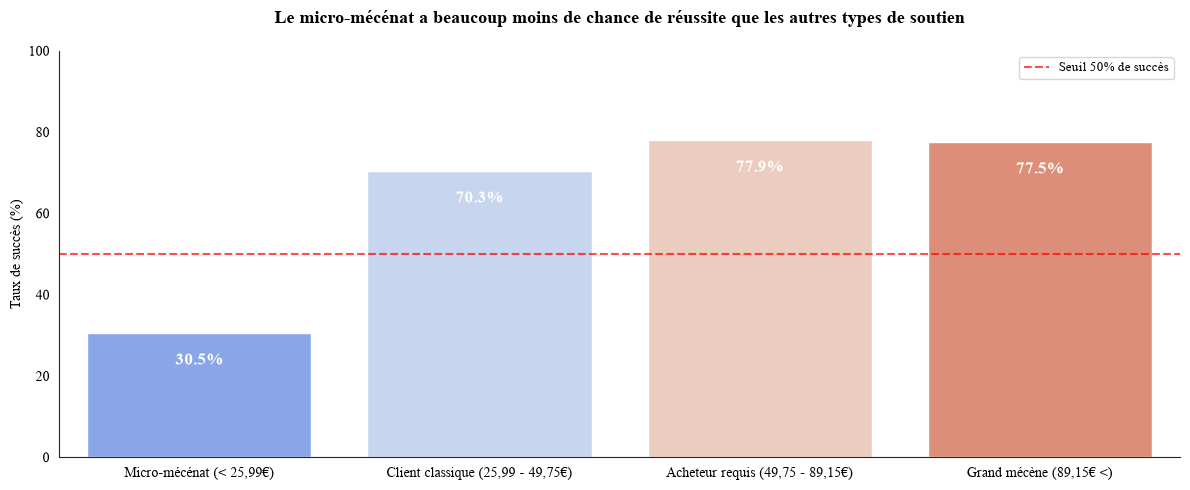

In [26]:
success_rate_backer_profile = df_completed.groupby('backer_profile_qcut', observed=False)['is_success'].mean() * 100
success_rate_backer_profile = success_rate_backer_profile.reindex(ordre_qcut)

# 3. Création de la figure
plt.figure(figsize=(12, 5)) # Hauteur légèrement augmentée pour le confort de lecture

bars = sns.barplot(
    x=success_rate_backer_profile.index, 
    y=success_rate_backer_profile.values, 
    palette='coolwarm'
)

# 4. Personnalisation esthétique
plt.title("Le micro-mécénat a beaucoup moins de chance de réussite que les autres types de soutien", fontsize=13, fontweight='bold', pad=20)
plt.ylabel("Taux de succès (%)", fontsize=10)
plt.xlabel("") # Les labels de l'axe X suffisent à eux-mêmes
plt.ylim(0, 100) # Échelle fixe pour ne pas fausser la perception

# Ligne horizontale du seuil de 50%
plt.axhline(
    50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

# 5. Ajout des annotations avec sécurité pour les valeurs nulles
for bar in bars.patches:
    height = bar.get_height()
    # On ajoute une condition pour ne rien écrire si la barre est à 0 (ex: Aucun soutien)
    if pd.notnull(height) and height > 0: 
        plt.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, -25), # Place le texte à l'intérieur de la barre
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='white'
        )


plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

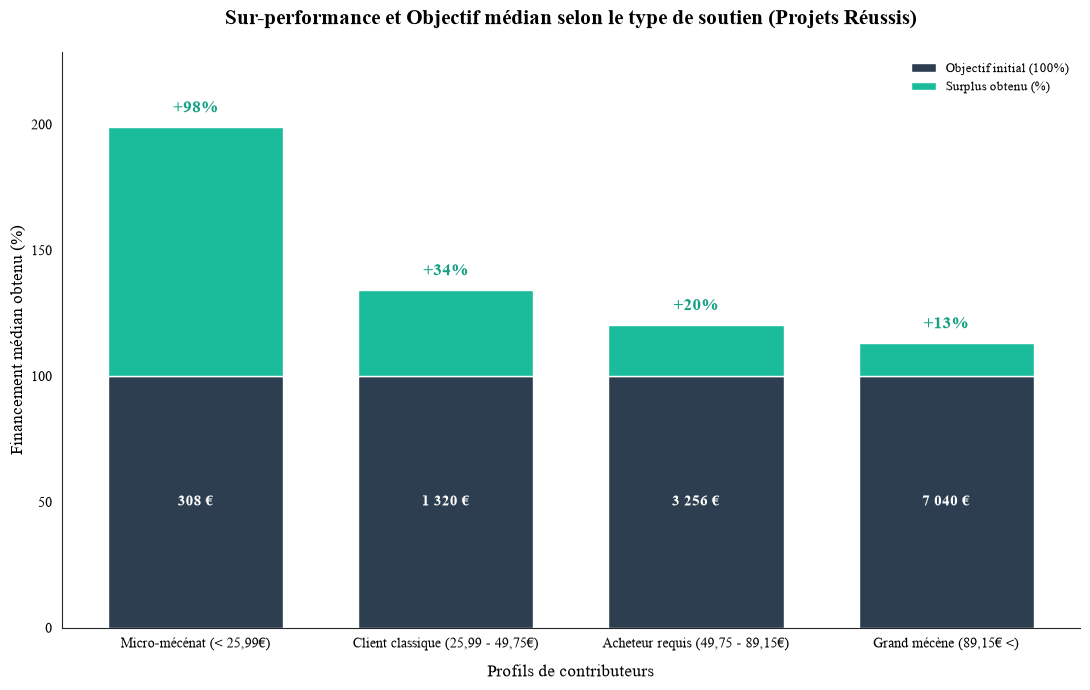

In [27]:

basket_perf = df_success.groupby('backer_profile_qcut', observed=True).agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median') # Ajout du calcul de l'objectif médian en euros
).reset_index()

# Filtre et tri pour respecter l'ordre
basket_perf = basket_perf[basket_perf['backer_profile_qcut'].isin(ordre_qcut)]
basket_perf['backer_profile_qcut'] = pd.Categorical(basket_perf['backer_profile_qcut'], categories=ordre_qcut, ordered=True)
basket_perf = basket_perf.sort_values('backer_profile_qcut')

# 2. Calculs pour le graphique empilé
basket_perf['base_100'] = 100
basket_perf['surplus_pct'] = basket_perf['median_funded'] - 100

# 3. Création de la figure
plt.figure(figsize=(11, 7))

# --- Tracé de la base (L'objectif validé à 100%) ---
plt.bar(
    basket_perf['backer_profile_qcut'], 
    basket_perf['base_100'], 
    color='#2c3e50', 
    label="Objectif initial (100%)",
    width=0.7
)

# --- Tracé du surplus (Empilé au-dessus de la base) ---
plt.bar(
    basket_perf['backer_profile_qcut'], 
    basket_perf['surplus_pct'], 
    bottom=basket_perf['base_100'], 
    color='#1abc9c', 
    label="Surplus obtenu (%)",
    width=0.7
)

# 4. Ajout des annotations de texte
for i in range(len(basket_perf)):
    base = basket_perf['base_100'].iloc[i]
    surplus = basket_perf['surplus_pct'].iloc[i]
    total = basket_perf['median_funded'].iloc[i]
    goal = basket_perf['median_goal'].iloc[i]
    
    # Texte dans le socle : Montant en euros + (100%)
    plt.annotate(
        f"{int(goal):,} €".replace(',', ' '), # Le \n permet de sauter une ligne
        (i, base / 2), 
        ha='center', va='center',
        fontsize=11, fontweight='bold', color='white'
    )
    
    # Texte du surplus (+X%) au-dessus de la barre
    if surplus > 0:
        plt.annotate(
            f"+{int(surplus)}%",
            (i, total),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#16a085'
        )

# 5. Personnalisation esthétique
plt.title("Sur-performance et Objectif médian selon le type de soutien (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Profils de contributeurs", fontsize=12, labelpad=10)
plt.ylabel("Financement médian obtenu (%)", fontsize=12)

# Ajustement de l'axe Y
plt.ylim(0, basket_perf['median_funded'].max() * 1.15)

sns.despine()
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

Les projets qui se reposent sur des micro-mécènes pour réussir ont des objectifs moins élevés et ont besoin de moins de contributeurs, mais leur chance de réussite est limitée comparée aux autres types de soutien. Il est donc capital pour les entrepreneurs d'attirer des profils plus qualitatifs et plus engagés pour maximiser leur chance de réussite.

En revanche lorsqu'on s'attarde sur la performance des projets réussis, les projets dont le type de soutien est micro-mécène performe 2 fois plus que ceux qui ont des grands mécènes.

## Catégories de projets

### Distribution par secteur

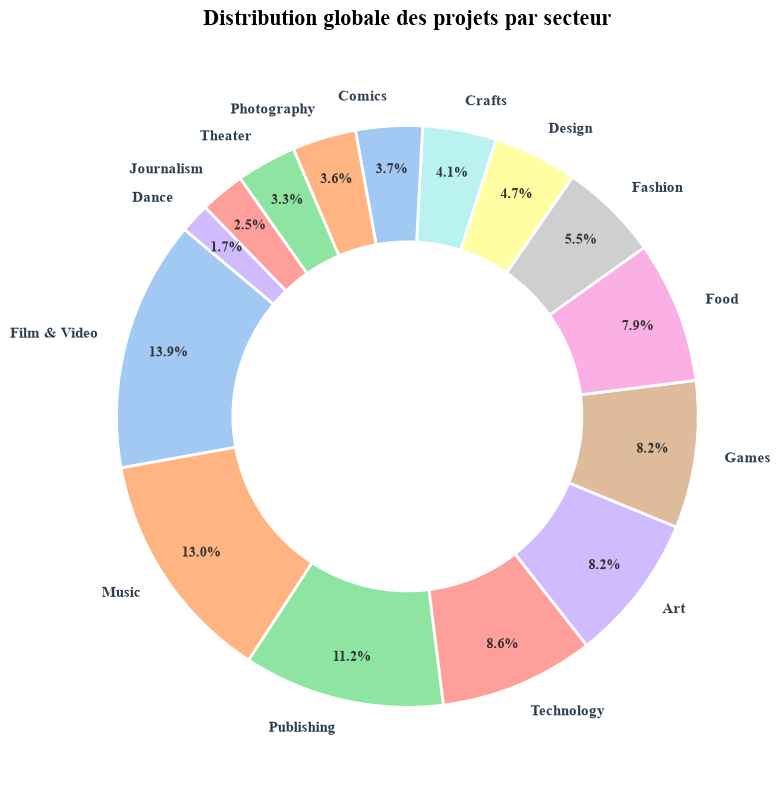

In [28]:
sector_counts = kickstarter_df['main_category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 8))

colors = sns.color_palette('pastel')[0:len(sector_counts)]

wedges, texts, autotexts = ax.pie(
    sector_counts, 
    labels=sector_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) # Le 'width' évide le centre
)

plt.setp(texts, fontsize=11, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=10, fontweight='bold', color='#333333')

plt.title("Distribution globale des projets par secteur", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

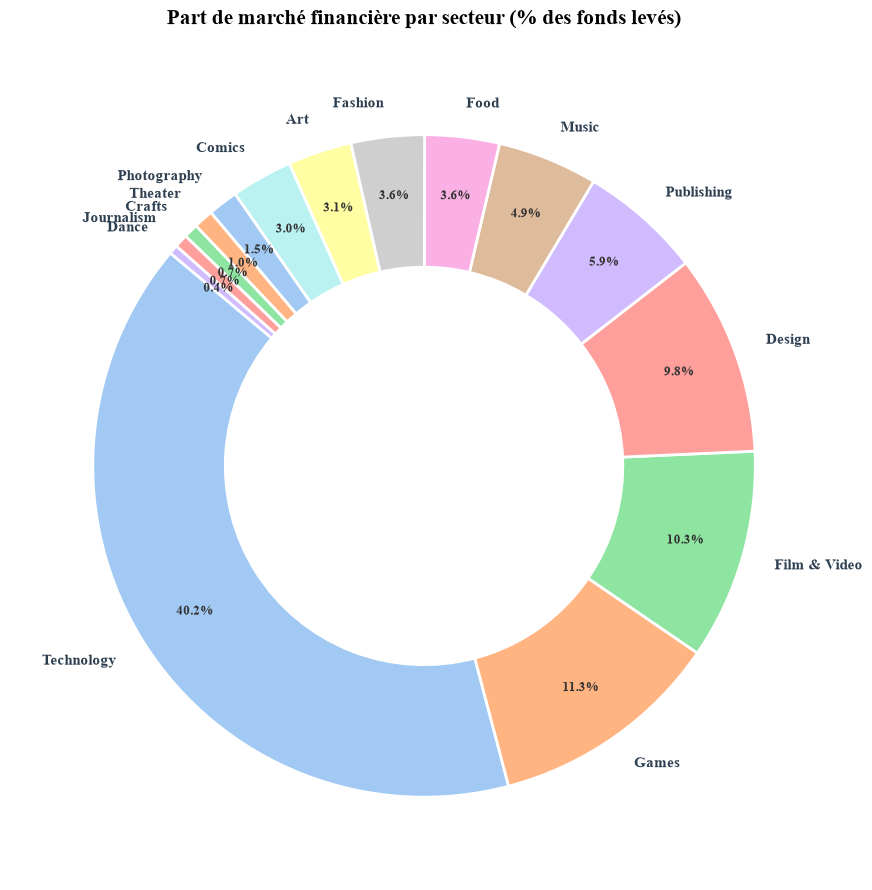

In [29]:
sector_pledged = kickstarter_df.groupby('main_category')['pledged_eur'].sum().sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 9))

colors = sns.color_palette('pastel')[0:len(sector_pledged)]

wedges, texts, autotexts = ax.pie(
    sector_pledged,
    labels=sector_pledged.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

plt.setp(texts, fontsize=11, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=9, fontweight='bold', color='#333333')

plt.title("Part de marché financière par secteur (% des fonds levés)", fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Performance par catégorie principale
* Top & Flop des catégories en termes de taux de succès et de fonds levés.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3027474199.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_success, x='success_rate', y='main_category', palette='viridis', ax=ax1)
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3027474199.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_funds, x='total_pledged', y='main_category', palette='rocket', ax=ax2)


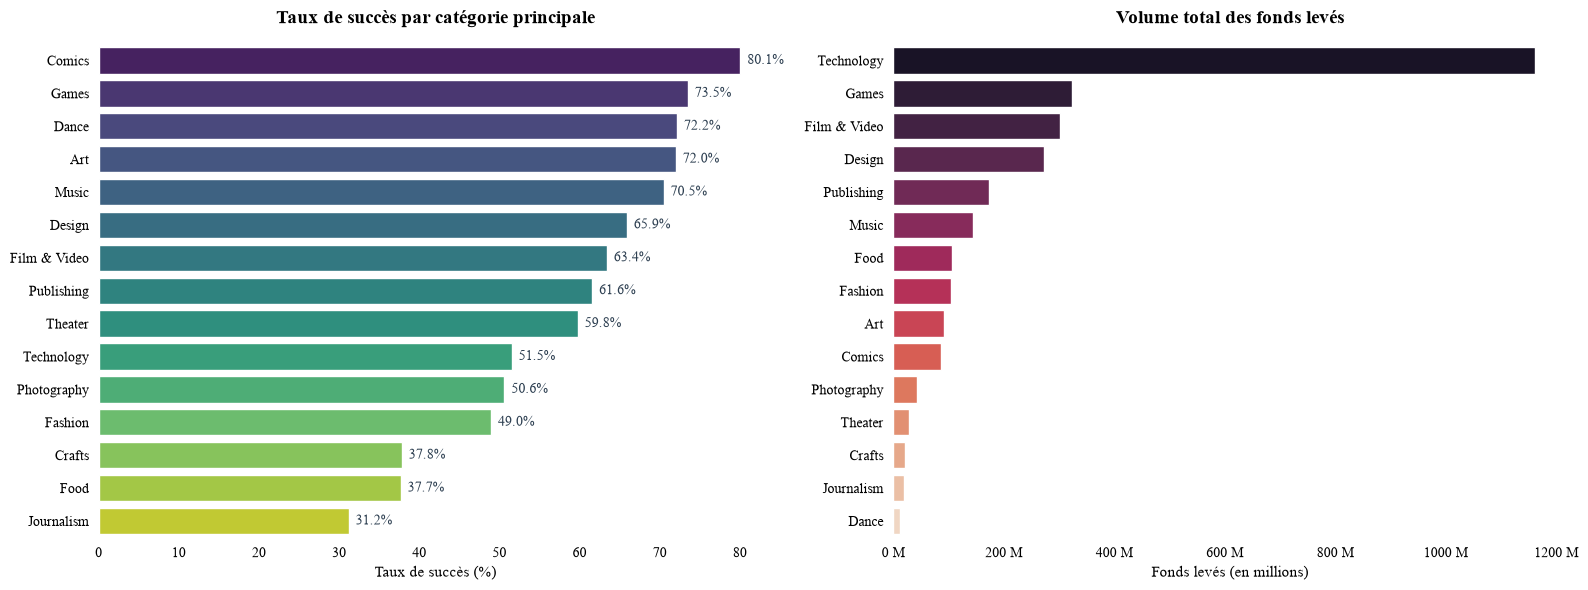

In [30]:
# Calcul du taux de succès et de la somme des fonds levés par catégorie
cat_stats = df_completed.groupby('main_category').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    total_pledged=('pledged_eur', 'sum') # Remplace 'pledged' par le nom exact de ta colonne monétaire si besoin
).reset_index()

# Tri des données pour créer les classements Top -> Flop
cat_success = cat_stats.sort_values('success_rate', ascending=False)
cat_funds = cat_stats.sort_values('total_pledged', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Taux de succès
sns.barplot(data=cat_success, x='success_rate', y='main_category', palette='viridis', ax=ax1)
ax1.set_title('Taux de succès par catégorie principale', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Taux de succès (%)', fontsize=11)
ax1.set_ylabel('') # Pas besoin de label Y, les noms suffisent

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, color='#2c3e50')

# Fonds levés
sns.barplot(data=cat_funds, x='total_pledged', y='main_category', palette='rocket', ax=ax2)
ax2.set_title('Volume total des fonds levés', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fonds levés (en millions)', fontsize=11)
ax2.set_ylabel('') 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x*1e-6:.0f} M"))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

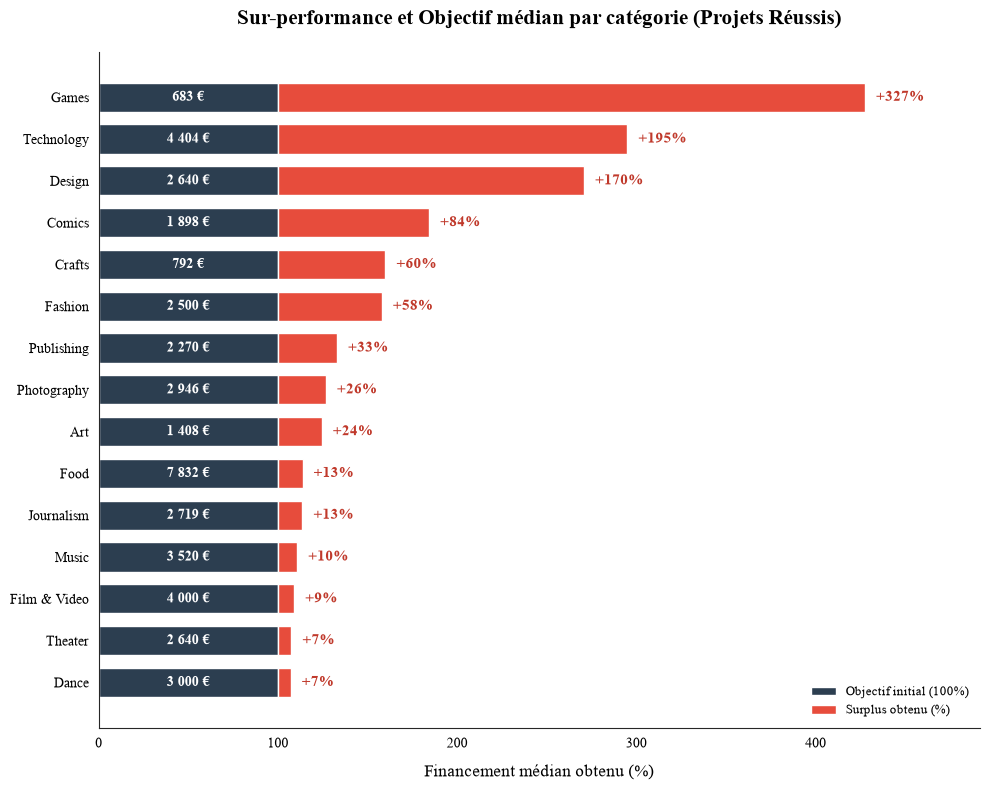

In [31]:
perf_cat_stats = df_success.groupby('main_category').agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

# Tri ascendant obligatoire pour que plt.barh place la plus grande valeur en haut
perf_cat_stats = perf_cat_stats.sort_values('median_funded', ascending=True)

# 2. Calculs pour le graphique empilé
perf_cat_stats['base_100'] = 100
perf_cat_stats['surplus_pct'] = perf_cat_stats['median_funded'] - 100

# 3. Création de la figure
plt.figure(figsize=(10, 8)) # Hauteur ajustée pour que toutes les catégories respirent

# Variables de positionnement
y_positions = range(len(perf_cat_stats))
categories = perf_cat_stats['main_category']

# --- Tracé de la base (L'objectif validé à 100%) ---
plt.barh(
    y_positions, 
    perf_cat_stats['base_100'], 
    color='#2c3e50', # Gris anthracite/Bleu nuit
    label="Objectif initial (100%)",
    height=0.7
)

# --- Tracé du surplus (Empilé à droite de la base) ---
plt.barh(
    y_positions, 
    perf_cat_stats['surplus_pct'], 
    left=perf_cat_stats['base_100'], # On empile sur l'axe X
    color='#e74c3c', # Rouge corail rappelant la palette 'flare'
    label="Surplus obtenu (%)",
    height=0.7
)

# 4. Ajout des annotations de texte
for i in range(len(perf_cat_stats)):
    base = perf_cat_stats['base_100'].iloc[i]
    surplus = perf_cat_stats['surplus_pct'].iloc[i]
    total = perf_cat_stats['median_funded'].iloc[i]
    goal = perf_cat_stats['median_goal'].iloc[i]
    
    # Texte dans le socle (100%) : Montant médian en €
    plt.annotate(
        f"{int(goal):,} €".replace(',', ' '), 
        (base / 2, i), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    # Texte du surplus (+X%) à la fin de la barre
    if surplus > 0:
        plt.annotate(
            f"+{int(surplus)}%",
            (total, i),
            xytext=(8, 0), textcoords='offset points', # Décalage sur l'axe X
            ha='left', va='center',
            fontsize=11, fontweight='bold', color='#c0392b'
        )

# 5. Personnalisation esthétique
plt.yticks(y_positions, categories) # Application des noms de catégories
plt.title("Sur-performance et Objectif médian par catégorie (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Financement médian obtenu (%)", fontsize=12, labelpad=10)
plt.ylabel("")

# Ajustement de l'axe X pour laisser la place aux étiquettes finales
plt.xlim(0, perf_cat_stats['median_funded'].max() * 1.15)

sns.despine()
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

Les secteurs qui sur-performent le plus sur les projets réussis sont les jeux, la technologie et le design.

### Focus sous-catégorie
On a vu avec le test de corrélation que la sous-catégorie a une influence plus forte sur l'issue de la campagne.
* Les sous-catégories à fort potentiel (celles qui dépassent largement leur médiane sectorielle cat_median_pledged_eur).

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/1498373340.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


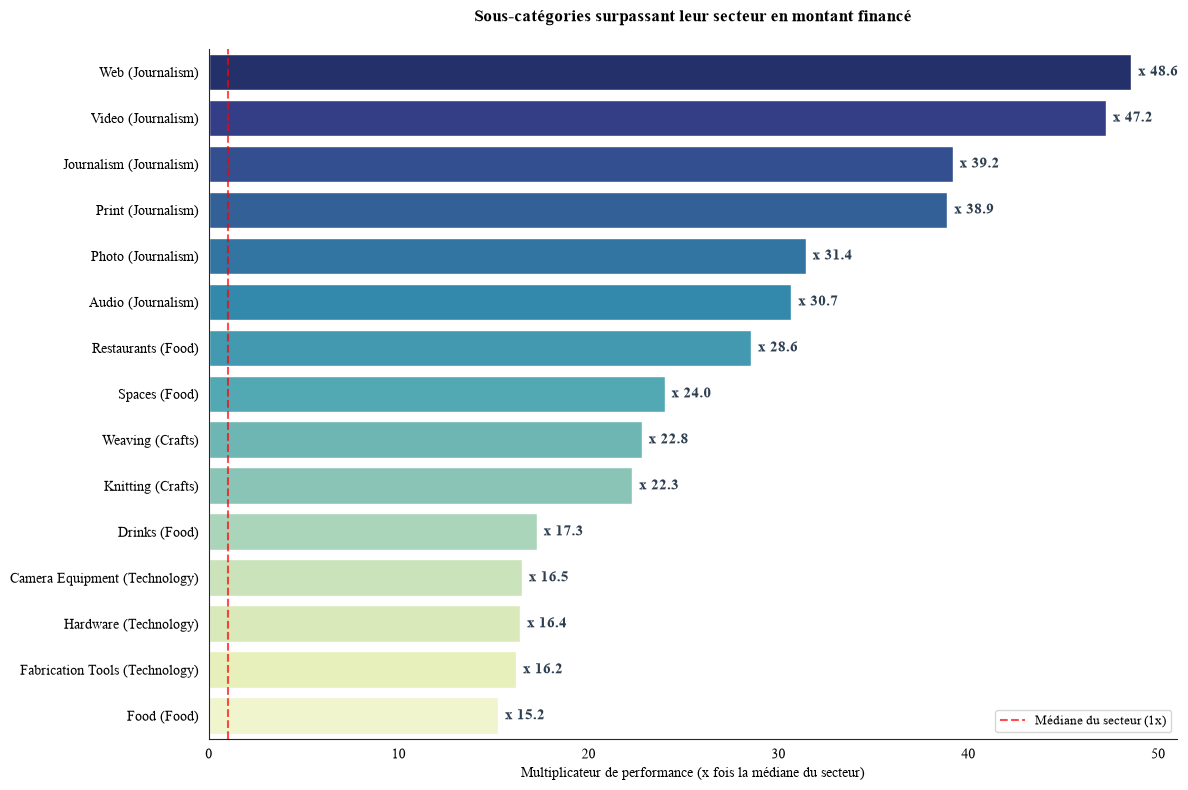

In [32]:
# On calcule la médiane réelle pour chaque sous-catégorie, ainsi que le volume
subcat_stats = df_success.groupby(['main_category', 'sub_category', 'cat_median_pledged_eur']).agg(
    sub_median=('pledged_eur', 'median'),
).reset_index()

df_perf = pd.merge(subcat_stats, cat_stats, on='main_category')

# Indice de Surperformance
df_perf['perf_multiplier'] = df_perf['sub_median'] / df_perf['cat_median_pledged_eur']

# Top 15 des sous-catégories à plus fort potentiel
top_subcats = df_perf.sort_values('perf_multiplier', ascending=False).head(15)

top_subcats['label'] = top_subcats['sub_category'] + ' (' + top_subcats['main_category'] + ')'

plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=top_subcats, 
    x='perf_multiplier', 
    y='label', 
    palette='YlGnBu_r' 
)

plt.title("Sous-catégories surpassant leur secteur en montant financé", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Multiplicateur de performance (x fois la médiane du secteur)", fontsize=10)
plt.ylabel("")

plt.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Médiane du secteur (1x)')
plt.legend(loc='lower right')

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"x {width:.1f}",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

### Objectif VS réalité par secteur
* Quelles catégories demandent les objectifs financiers les plus réalistes/élevés ?

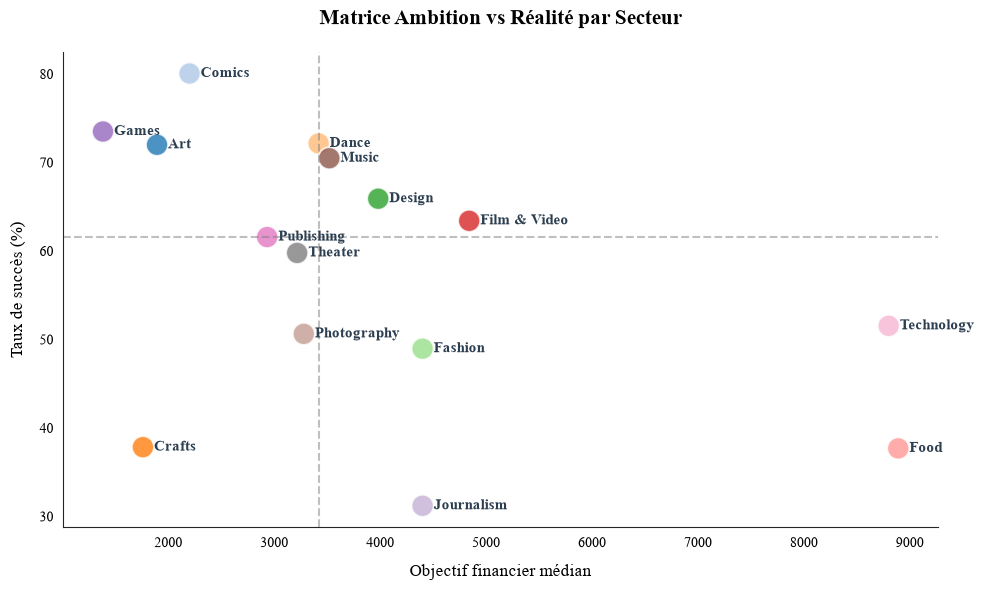

In [33]:
sector_stats = df_completed.groupby('main_category', observed=False).agg(
    median_goal=('goal_eur', 'median'), # L'objectif (Ambition)
    success_rate=('is_success', lambda x: x.mean() * 100) # La réalité (Réalisme)
).reset_index()

# Nuage de points
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=sector_stats,
    x='median_goal',
    y='success_rate',
    hue='main_category',
    s=250, # Taille des bulles
    palette='tab20', # Palette avec beaucoup de couleurs distinctes
    legend=False,
    alpha=0.8
)

for i in range(sector_stats.shape[0]):
    plt.annotate(
        sector_stats['main_category'].iloc[i],
        (sector_stats['median_goal'].iloc[i], sector_stats['success_rate'].iloc[i]),
        xytext=(8, 0), textcoords='offset points', 
        ha='left', va='center',
        fontsize=11, fontweight='bold', color='#2c3e50'
    )

plt.axvline(x=sector_stats['median_goal'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=sector_stats['success_rate'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title("Matrice Ambition vs Réalité par Secteur", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Objectif financier médian", fontsize=12, labelpad=10)
plt.ylabel("Taux de succès (%)", fontsize=12, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

### Meilleures niches par secteur

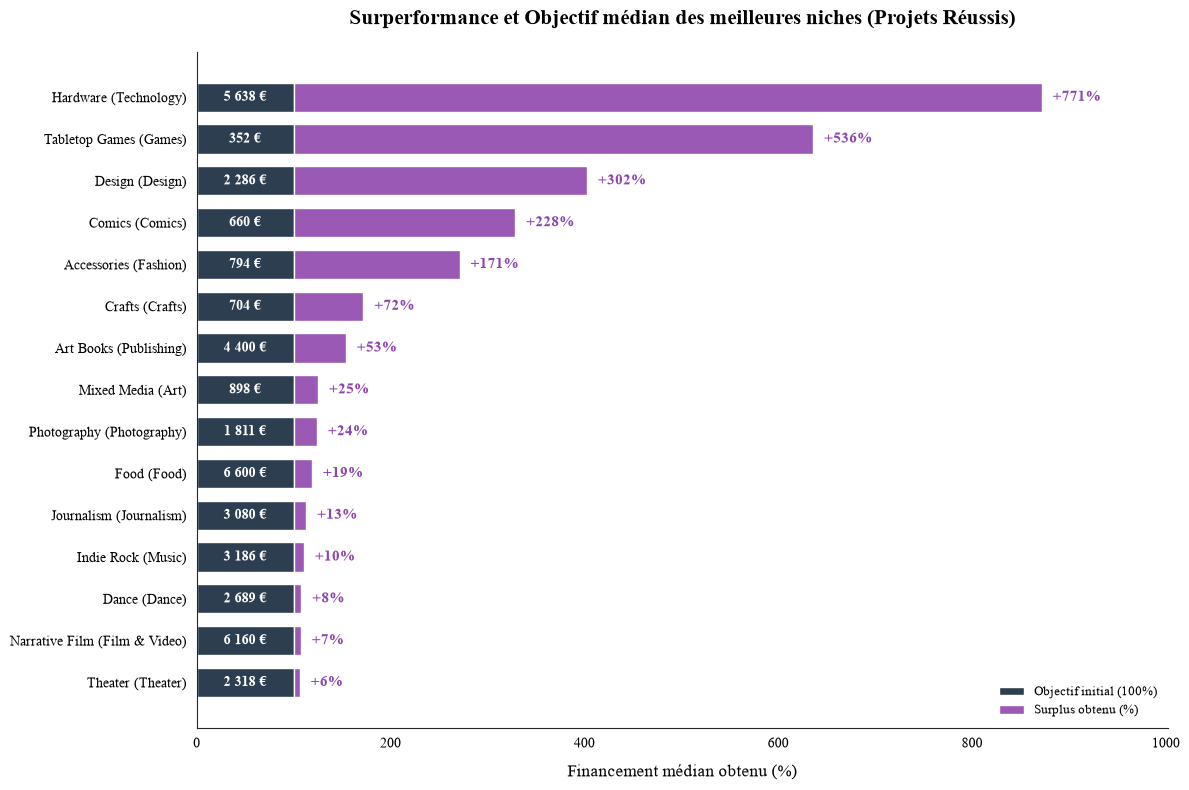

In [34]:
niche_success = df_completed.groupby(['main_category', 'sub_category']).agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

niche_funding = df_success.groupby(['main_category', 'sub_category']).agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median') # Ajout du calcul en euros ici
).reset_index()

# Fusion et filtrage
niche_stats = pd.merge(niche_success, niche_funding, on=['main_category', 'sub_category'])
niche_stats = niche_stats[niche_stats['volume'] >= 30]

# Sélection de la meilleure niche par catégorie principale
niche_stats = niche_stats.sort_values(['main_category', 'success_rate'], ascending=[True, False])
best_niches = niche_stats.groupby('main_category').head(1).copy()

# Création du label propre
best_niches['label'] = best_niches['sub_category'] + ' (' + best_niches['main_category'] + ')'

# Tri ascendant indispensable pour que plt.barh place la plus performante tout en haut
best_niches = best_niches.sort_values('median_funded', ascending=True)

# 2. Calculs pour le graphique empilé
best_niches['base_100'] = 100
best_niches['surplus_pct'] = best_niches['median_funded'] - 100

# 3. Création de la figure
plt.figure(figsize=(12, 8))

y_positions = range(len(best_niches))
labels = best_niches['label']

# --- Tracé de la base (L'objectif validé à 100%) ---
plt.barh(
    y_positions, 
    best_niches['base_100'], 
    color='#2c3e50', 
    label="Objectif initial (100%)",
    height=0.7
)

# --- Tracé du surplus (Empilé à droite) ---
plt.barh(
    y_positions, 
    best_niches['surplus_pct'], 
    left=best_niches['base_100'], 
    color='#9b59b6', # Violet profond inspiré de la palette 'magma'
    label="Surplus obtenu (%)",
    height=0.7
)

# 4. Ajout des annotations de texte
for i in range(len(best_niches)):
    base = best_niches['base_100'].iloc[i]
    surplus = best_niches['surplus_pct'].iloc[i]
    total = best_niches['median_funded'].iloc[i]
    goal = best_niches['median_goal'].iloc[i]
    
    # Texte dans le socle (100%) : Montant médian en €
    plt.annotate(
        f"{int(goal):,} €".replace(',', ' '), 
        (base / 2, i), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    # Texte du surplus (+X%) à la fin de la barre
    if surplus > 0:
        plt.annotate(
            f"+{int(surplus)}%",
            (total, i),
            xytext=(8, 0), textcoords='offset points',
            ha='left', va='center',
            fontsize=11, fontweight='bold', color='#8e44ad'
        )

# 5. Personnalisation esthétique
plt.yticks(y_positions, labels) 
plt.title("Surperformance et Objectif médian des meilleures niches (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Financement médian obtenu (%)", fontsize=12, labelpad=10)
plt.ylabel("")

# Ajustement de l'axe X pour que les labels de droite ne soient pas coupés
plt.xlim(0, best_niches['median_funded'].max() * 1.15)

sns.despine()
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

* Les secteurs les plus performants sont les jeux, l'art et les comics.
* Les secteurs les plus ambitieux sont la technologie, l'alimentaire, la mode.
* Les secteurs qui ont des objectifs les plus réalistes sont la danse, la musique, le design et les films.
* Les secteurs les moins performants sont l'artisanat et le journalisme.

Si le projet est dans une catégorie moins performante, il est néanmoins intéressant de sélectionner une niche qui surperforme comme par exemple le web pour le journalisme ou le tricot pour l'artisanat.

Les niches les plus performantes de tous les temps sont le hardware (technologie), les jeux de table (jeux), le design (design), les comics (comics) et les accessoires (mode).

## Géographie

### Répartition mondiale
* D'où viennent la majorité des projets ?

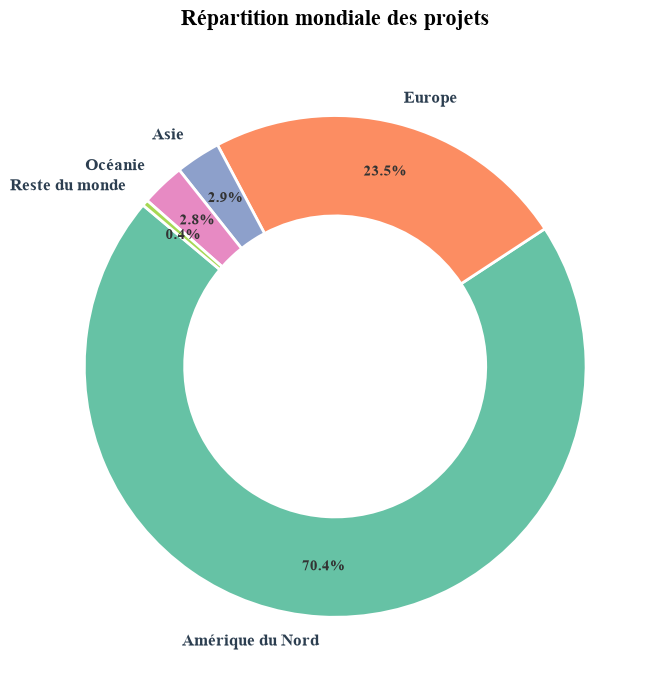

In [35]:
region_counts = kickstarter_df['region'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))

colors = sns.color_palette('Set2')[0:len(region_counts)]

wedges, texts, autotexts = ax.pie(
    region_counts, 
    labels=region_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=colors,
    pctdistance=0.80, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
plt.setp(texts, fontsize=12, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=11, fontweight='bold', color='#333333')

plt.title("Répartition mondiale des projets", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Taux de succès géographique
* Certaines régions/pays performent-ils mieux que d'autres sur Kickstarter ?

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/2309312007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


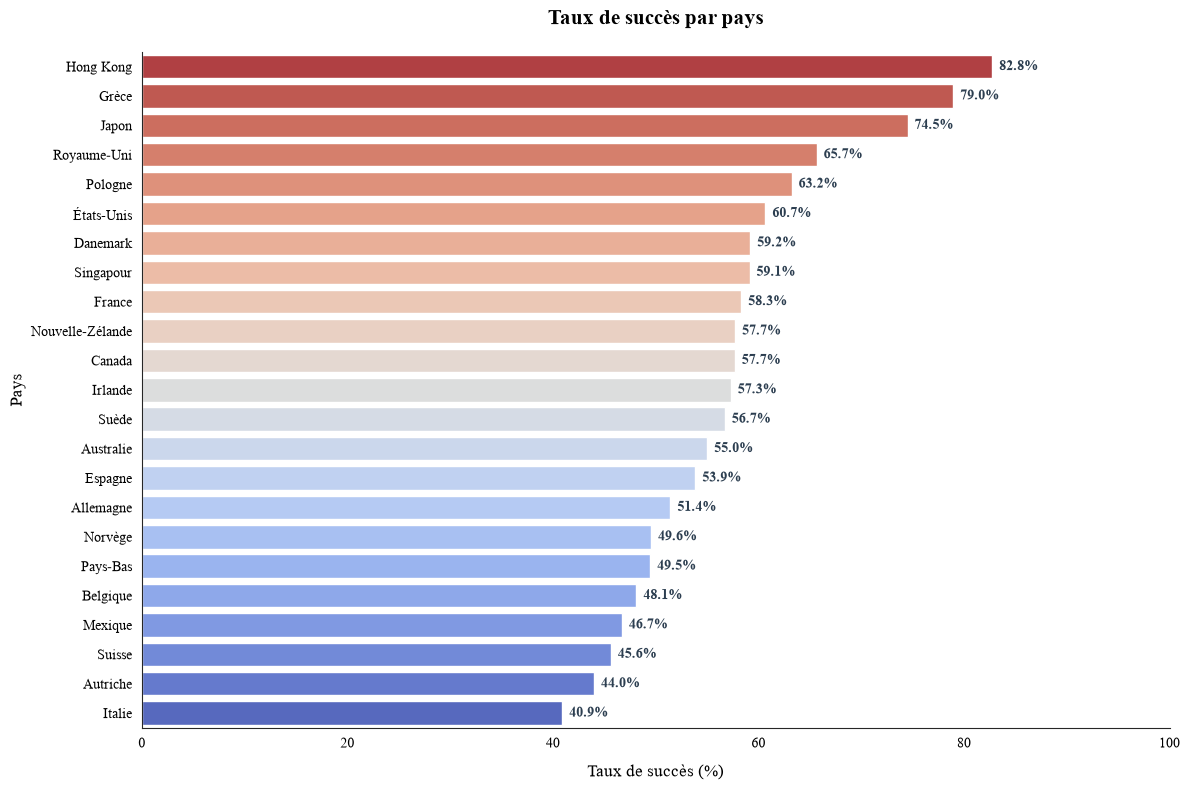

In [36]:
country_stats = df_completed.groupby('country').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

country_stats = country_stats[country_stats['volume'] >= 100]
country_stats = country_stats.sort_values('success_rate', ascending=False)


plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=country_stats, 
    x='success_rate', 
    y='country', 
    palette='coolwarm_r'
)

plt.title("Taux de succès par pays", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Taux de succès (%)", fontsize=12, labelpad=10)
plt.ylabel("Pays", fontsize=12)
plt.xlim(0, 100)

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3472096996.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


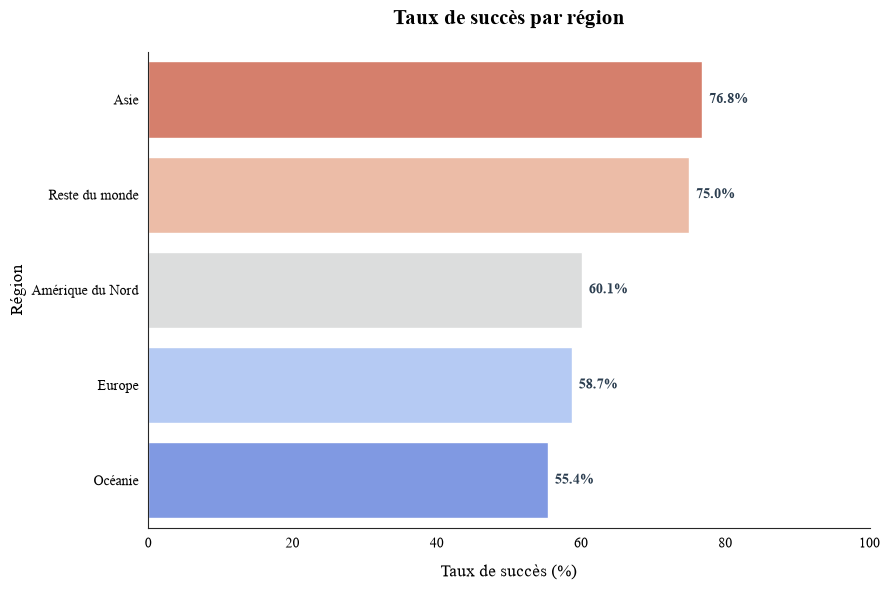

In [37]:
region_stats = df_completed.groupby('region').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

region_stats = region_stats.sort_values('success_rate', ascending=False)
region_stats = region_stats[region_stats['volume'] >= 100]

plt.figure(figsize=(9, 6))
barplot = sns.barplot(
    data=region_stats, 
    x='success_rate', 
    y='region', 
    palette='coolwarm_r'
)

plt.title("Taux de succès par région", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Taux de succès (%)", fontsize=12, labelpad=10)
plt.ylabel("Région", fontsize=12)
plt.xlim(0, 100)

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

## Signal et leviers marketing

### Media
* Impact direct de la vidéo explicative et de la phase de pré-lancement sur la réussite.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/2293556765.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=video_stats, x='has_video', y='success_rate', palette=['#c0392b', '#27ae60'], ax=ax1)
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/2293556765.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prelaunch_stats, x='prelaunch_activated', y='success_rate', palette=['#c0392b', '#27ae60'], ax=ax2)


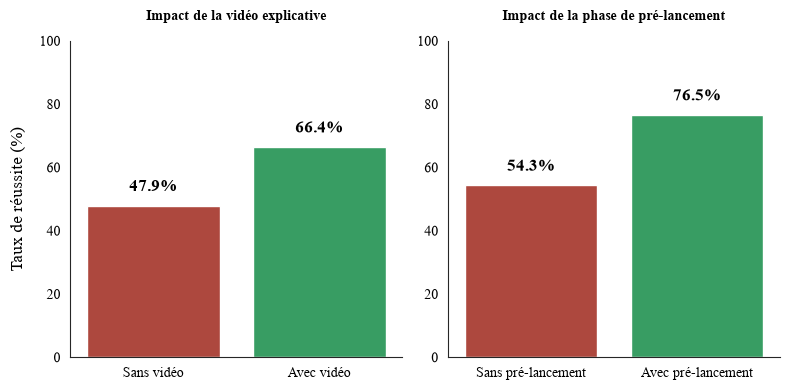

In [38]:
video_stats = df_completed.groupby('has_video').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

video_stats['has_video'] = video_stats['has_video'].replace({True: 'Avec vidéo', False: 'Sans vidéo', 1: 'Avec vidéo', 0: 'Sans vidéo'})

prelaunch_stats = df_completed.groupby('prelaunch_activated').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

prelaunch_stats['prelaunch_activated'] = prelaunch_stats['prelaunch_activated'].replace({True: 'Avec pré-lancement', False: 'Sans pré-lancement', 1: 'Avec pré-lancement', 0: 'Sans pré-lancement'})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))


sns.barplot(data=video_stats, x='has_video', y='success_rate', palette=['#c0392b', '#27ae60'], ax=ax1)
ax1.set_title("Impact de la vidéo explicative", fontsize=10, fontweight='bold', pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Taux de réussite (%)", fontsize=12, labelpad=10)
ax1.set_ylim(0, 100)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=12, fontweight='bold')


sns.barplot(data=prelaunch_stats, x='prelaunch_activated', y='success_rate', palette=['#c0392b', '#27ae60'], ax=ax2)
ax2.set_title("Impact de la phase de pré-lancement", fontsize=10, fontweight='bold', pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_ylim(0, 100)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

La présence d'une vidéo de présentation ou la création d'une page de pré-lancement améliorent le signal envoyé aux futurs contributeurs, augmentant les chances de réussite.

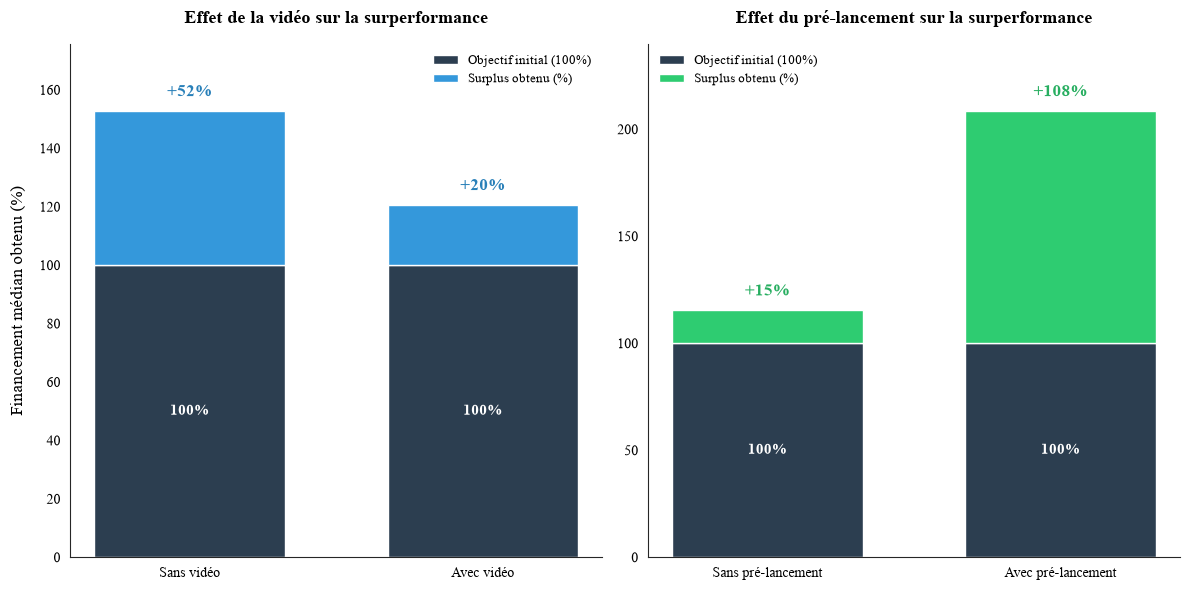

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PRÉPARATION DES DONNÉES ET AGRÉGATIONS
# ==========================================

# Agrégation Vidéo
video_perf = df_success.groupby('has_video').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

video_perf['has_video'] = video_perf['has_video'].replace({
    True: 'Avec vidéo', False: 'Sans vidéo', 1: 'Avec vidéo', 0: 'Sans vidéo'
})
# Forcer l'ordre d'affichage
video_perf['has_video'] = pd.Categorical(video_perf['has_video'], categories=['Sans vidéo', 'Avec vidéo'], ordered=True)
video_perf = video_perf.sort_values('has_video')

# Agrégation Pré-lancement
prelaunch_perf = df_success.groupby('prelaunch_activated').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

prelaunch_perf['prelaunch_activated'] = prelaunch_perf['prelaunch_activated'].replace({
    True: 'Avec pré-lancement', False: 'Sans pré-lancement', 1: 'Avec pré-lancement', 0: 'Sans pré-lancement'
})
# Forcer l'ordre d'affichage
prelaunch_perf['prelaunch_activated'] = pd.Categorical(prelaunch_perf['prelaunch_activated'], categories=['Sans pré-lancement', 'Avec pré-lancement'], ordered=True)
prelaunch_perf = prelaunch_perf.sort_values('prelaunch_activated')

# Calculs pour l'empilement
video_perf['base_100'] = 100
video_perf['surplus_pct'] = video_perf['median_funded'] - 100

prelaunch_perf['base_100'] = 100
prelaunch_perf['surplus_pct'] = prelaunch_perf['median_funded'] - 100

# ==========================================
# 2. CRÉATION DES GRAPHIQUES
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
bar_width = 0.65

# ------------------------------------------
# AXE 1 : VIDÉO
# ------------------------------------------
# Socle
ax1.bar(video_perf['has_video'], video_perf['base_100'], color='#2c3e50', width=bar_width, label="Objectif initial (100%)")
# Surplus
ax1.bar(video_perf['has_video'], video_perf['surplus_pct'], bottom=video_perf['base_100'], color='#3498db', width=bar_width, label="Surplus obtenu (%)")

ax1.set_title("Effet de la vidéo sur la surperformance", fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel("Financement médian obtenu (%)", fontsize=12, labelpad=10)
ax1.set_ylim(0, video_perf['median_funded'].max() * 1.15)
ax1.legend(loc='upper right', frameon=False)

# Annotations Axe 1
for i in range(len(video_perf)):
    base = video_perf['base_100'].iloc[i]
    surplus = video_perf['surplus_pct'].iloc[i]
    total = video_perf['median_funded'].iloc[i]
    
    # Texte du socle
    ax1.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Texte du surplus
    if surplus > 0:
        ax1.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2980b9')

# ------------------------------------------
# AXE 2 : PRÉ-LANCEMENT
# ------------------------------------------
# Socle
ax2.bar(prelaunch_perf['prelaunch_activated'], prelaunch_perf['base_100'], color='#2c3e50', width=bar_width, label="Objectif initial (100%)")
# Surplus
ax2.bar(prelaunch_perf['prelaunch_activated'], prelaunch_perf['surplus_pct'], bottom=prelaunch_perf['base_100'], color='#2ecc71', width=bar_width, label="Surplus obtenu (%)")

ax2.set_title("Effet du pré-lancement sur la surperformance", fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, prelaunch_perf['median_funded'].max() * 1.15)
ax2.legend(loc='upper left', frameon=False)

# Annotations Axe 2
for i in range(len(prelaunch_perf)):
    base = prelaunch_perf['base_100'].iloc[i]
    surplus = prelaunch_perf['surplus_pct'].iloc[i]
    total = prelaunch_perf['median_funded'].iloc[i]
    
    # Texte du socle
    ax2.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Texte du surplus
    if surplus > 0:
        ax2.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#27ae60')

# ==========================================
# 3. FINITIONS ESTHÉTIQUES
# ==========================================
sns.despine()
plt.tight_layout()
plt.show()

En revanche les projets qui ont des vidéos ont moins de chances de sur-performer, tandis que l'activation d'une page de pré-lancement double la performance médiane.

### Recommandation de Kickstarter
* L'effet "Coup de cœur Kickstarter" sur le succès et la surperformance

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/3258487695.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=staff_success_stats, x='staff_pick_label', y='success_rate', palette=palette_staff, ax=ax1)


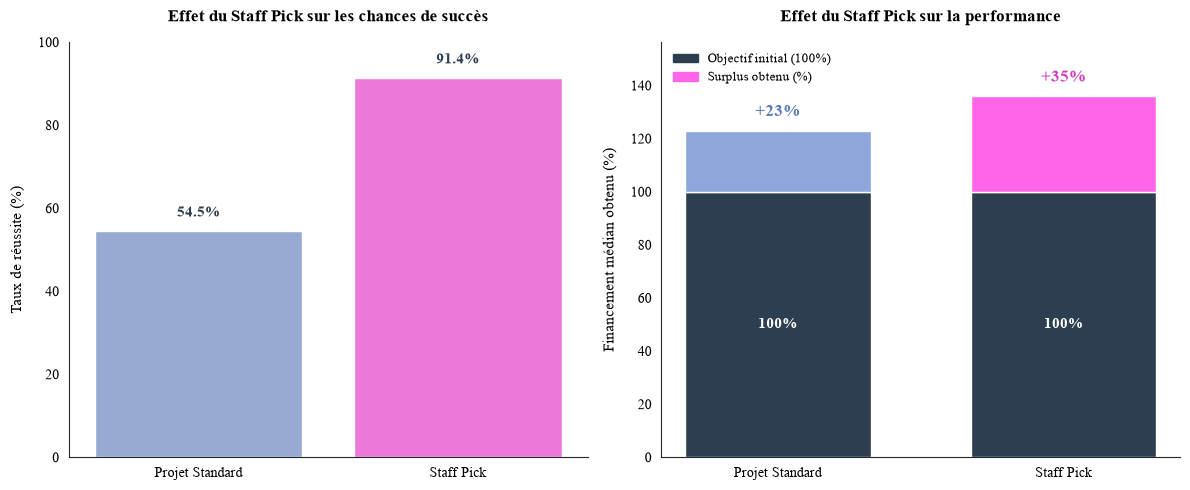

In [40]:
import matplotlib.patches as mpatches


labels_dict = {True: 'Staff Pick', False: 'Projet Standard', 1: 'Staff Pick', 0: 'Projet Standard'}

# Taux de succès
staff_success_stats = df_completed.groupby('staff_pick').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

staff_success_stats['staff_pick_label'] = staff_success_stats['staff_pick'].map(labels_dict)
staff_success_stats['staff_pick_label'] = pd.Categorical(staff_success_stats['staff_pick_label'], categories=['Projet Standard', 'Staff Pick'], ordered=True)
staff_success_stats = staff_success_stats.sort_values('staff_pick_label')

# Surperformance (Projets réussis uniquement)
staff_funded_stats = df_success.groupby('staff_pick').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

staff_funded_stats['staff_pick_label'] = staff_funded_stats['staff_pick'].map(labels_dict)
staff_funded_stats['staff_pick_label'] = pd.Categorical(staff_funded_stats['staff_pick_label'], categories=['Projet Standard', 'Staff Pick'], ordered=True)
staff_funded_stats = staff_funded_stats.sort_values('staff_pick_label')

# Calculs pour l'empilement
staff_funded_stats['base_100'] = 100
staff_funded_stats['surplus_pct'] = staff_funded_stats['median_funded'] - 100

# ==========================================
# 2. CRÉATION DES GRAPHIQUES
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
palette_staff = ['#8fa6da', '#ff65e8'] # Bleu gris et Magenta
bar_width = 0.65

# ------------------------------------------
# GRAPHIQUE 1 : Taux de succès (Classique)
# ------------------------------------------
sns.barplot(data=staff_success_stats, x='staff_pick_label', y='success_rate', palette=palette_staff, ax=ax1)
ax1.set_title("Effet du Staff Pick sur les chances de succès", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Taux de réussite (%)", fontsize=11, labelpad=10)
ax1.set_ylim(0, 100)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

# ------------------------------------------
# GRAPHIQUE 2 : Surperformance (Empilé)
# ------------------------------------------
# Socle
ax2.bar(staff_funded_stats['staff_pick_label'], staff_funded_stats['base_100'], color='#2c3e50', width=bar_width)
# Surplus (on utilise la palette_staff pour différencier les deux surperformances)
ax2.bar(staff_funded_stats['staff_pick_label'], staff_funded_stats['surplus_pct'], bottom=staff_funded_stats['base_100'], color=palette_staff, width=bar_width)

ax2.set_title("Effet du Staff Pick sur la performance", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("Financement médian obtenu (%)", fontsize=11, labelpad=10)
ax2.set_ylim(0, staff_funded_stats['median_funded'].max() * 1.15)

# Légende personnalisée pour ax2
patch_base = mpatches.Patch(color='#2c3e50', label='Objectif initial (100%)')
patch_surplus = mpatches.Patch(color='#ff65e8', label='Surplus obtenu (%)')
ax2.legend(handles=[patch_base, patch_surplus], loc='upper left', frameon=False)

# Annotations Axe 2
for i in range(len(staff_funded_stats)):
    base = staff_funded_stats['base_100'].iloc[i]
    surplus = staff_funded_stats['surplus_pct'].iloc[i]
    total = staff_funded_stats['median_funded'].iloc[i]
    
    # Texte du socle
    ax2.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Texte du surplus
    if surplus > 0:
        # Couleurs de texte adaptées pour contraster avec le fond blanc
        text_color = '#5b7db5' if i == 0 else '#d143bd' 
        
        ax2.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color=text_color)

# ==========================================
# 3. FINITIONS ESTHÉTIQUES
# ==========================================
sns.despine()
plt.tight_layout()
plt.show()

La recommandation de Kickstarter est un signal de preuve sociale pour les contributeurs : elle double les chances de réussite et augmente légèrement la performance médiane.

### Influence de la recommandation de Kickstarter sur la traction de contributeurs

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/636424280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/636424280.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


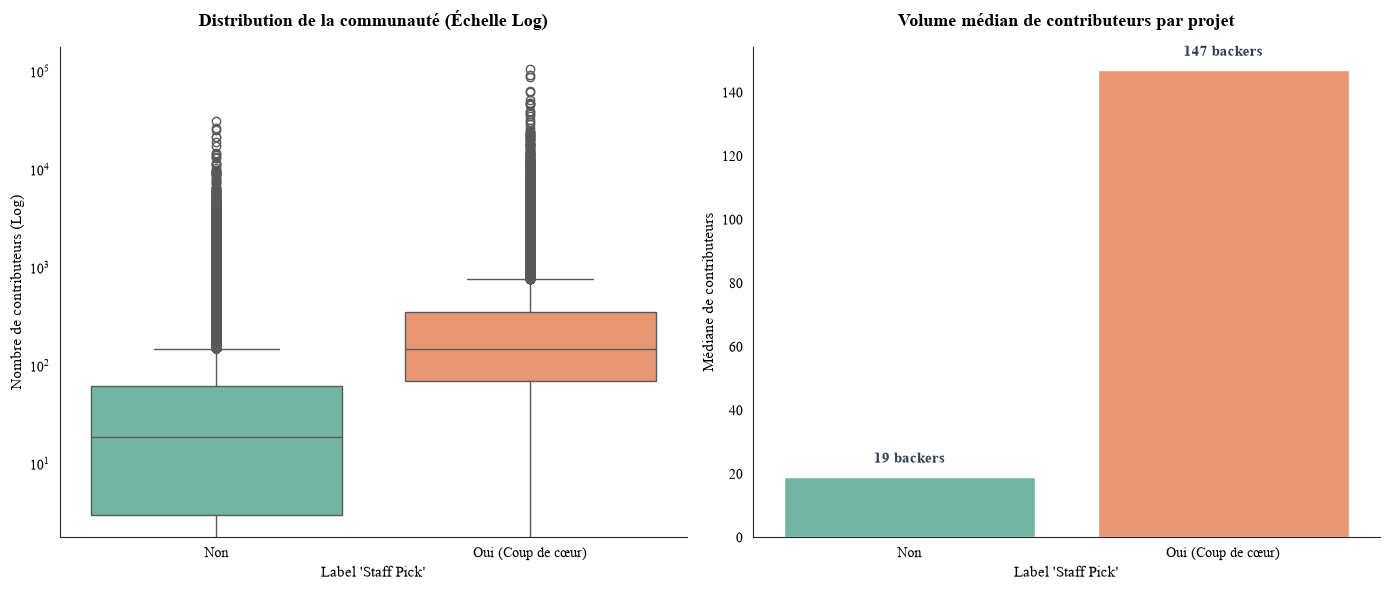

In [41]:
df_completed['staff_pick_label'] = df_completed['staff_pick'].map({True: 'Oui (Coup de cœur)', False: 'Non'})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphique 1 : Boxplot (Distribution au format Logarithmique) ---
sns.boxplot(
    data=df_completed, 
    x='staff_pick_label', 
    y='backers_count', 
    palette='Set2', 
    ax=ax1
)
ax1.set_yscale('log') # Astuce cruciale pour écraser les valeurs extrêmes
ax1.set_title("Distribution de la communauté (Échelle Log)", fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Label 'Staff Pick'", fontsize=11)
ax1.set_ylabel("Nombre de contributeurs (Log)", fontsize=11)

# --- Graphique 2 : Barplot (Comparaison des Médianes) ---
median_backers = df_completed.groupby('staff_pick_label', observed=True)['backers_count'].median().reset_index()

barplot = sns.barplot(
    data=median_backers, 
    x='staff_pick_label', 
    y='backers_count', 
    palette='Set2', 
    ax=ax2
)
ax2.set_title("Volume médian de contributeurs par projet", fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Label 'Staff Pick'", fontsize=11)
ax2.set_ylabel("Médiane de contributeurs", fontsize=11)

# Ajout des valeurs exactes sur le barplot
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())} backers",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

On comprend que le label Staff Pick a l'air d'avoir une influence sur le nombre de backers par projet. Obtenir le label change radicalement la dimension de la communauté attendue pour n'importe quel type de campagne.

### Typologie de soutien des projets Staff Pick

Les projets qui ont le label Staff Pick attirent-il des contributeurs plus qualitatifs ?

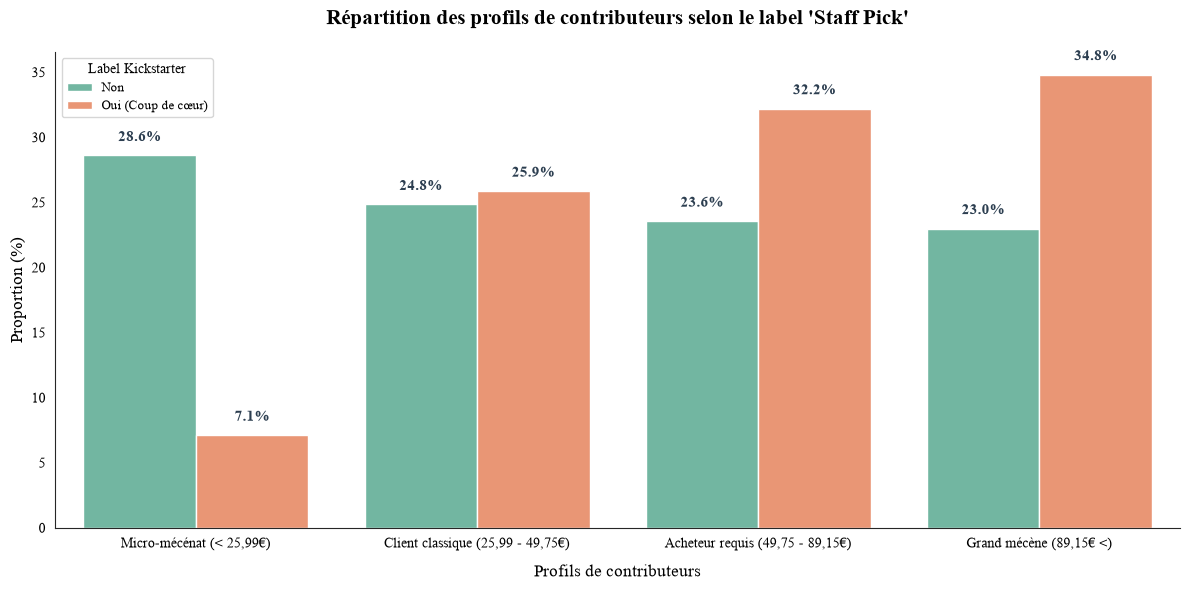

In [46]:
df_completed = kickstarter_df[kickstarter_df['state'].isin(['successful', 'failed', 'canceled'])].copy()

df_completed['staff_pick_label'] = df_completed['staff_pick'].map({True: 'Oui (Coup de cœur)', False: 'Non'})

df_filtered = df_completed[df_completed['backer_profile_qcut'].isin(ordre_qcut)]


prop_df = df_filtered.groupby(['staff_pick_label', 'backer_profile_qcut']).size().reset_index(name='count')
prop_df['proportion'] = prop_df.groupby('staff_pick_label')['count'].transform(lambda x: x / x.sum() * 100)


plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=prop_df,
    x='backer_profile_qcut',
    y='proportion',
    hue='staff_pick_label',
    palette='Set2',
    order=ordre_qcut
)


plt.title("Répartition des profils de contributeurs selon le label 'Staff Pick'", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Profils de contributeurs", fontsize=12, labelpad=10)
plt.ylabel("Proportion (%)", fontsize=12)
plt.legend(title="Label Kickstarter", loc='upper left')


for p in barplot.patches:
    if p.get_height() > 0:
        plt.annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                     fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

Le graphique nous montre en effet que le label Staff Pick attire des contributeurs qui ont un panier moyen beaucoup plus élevé que les projets qui n'ont pas le label.

### Optimisation du titre et de la description
* Impact de la longueur du nom et du blurb sur le taux de succès.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_8651/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='su

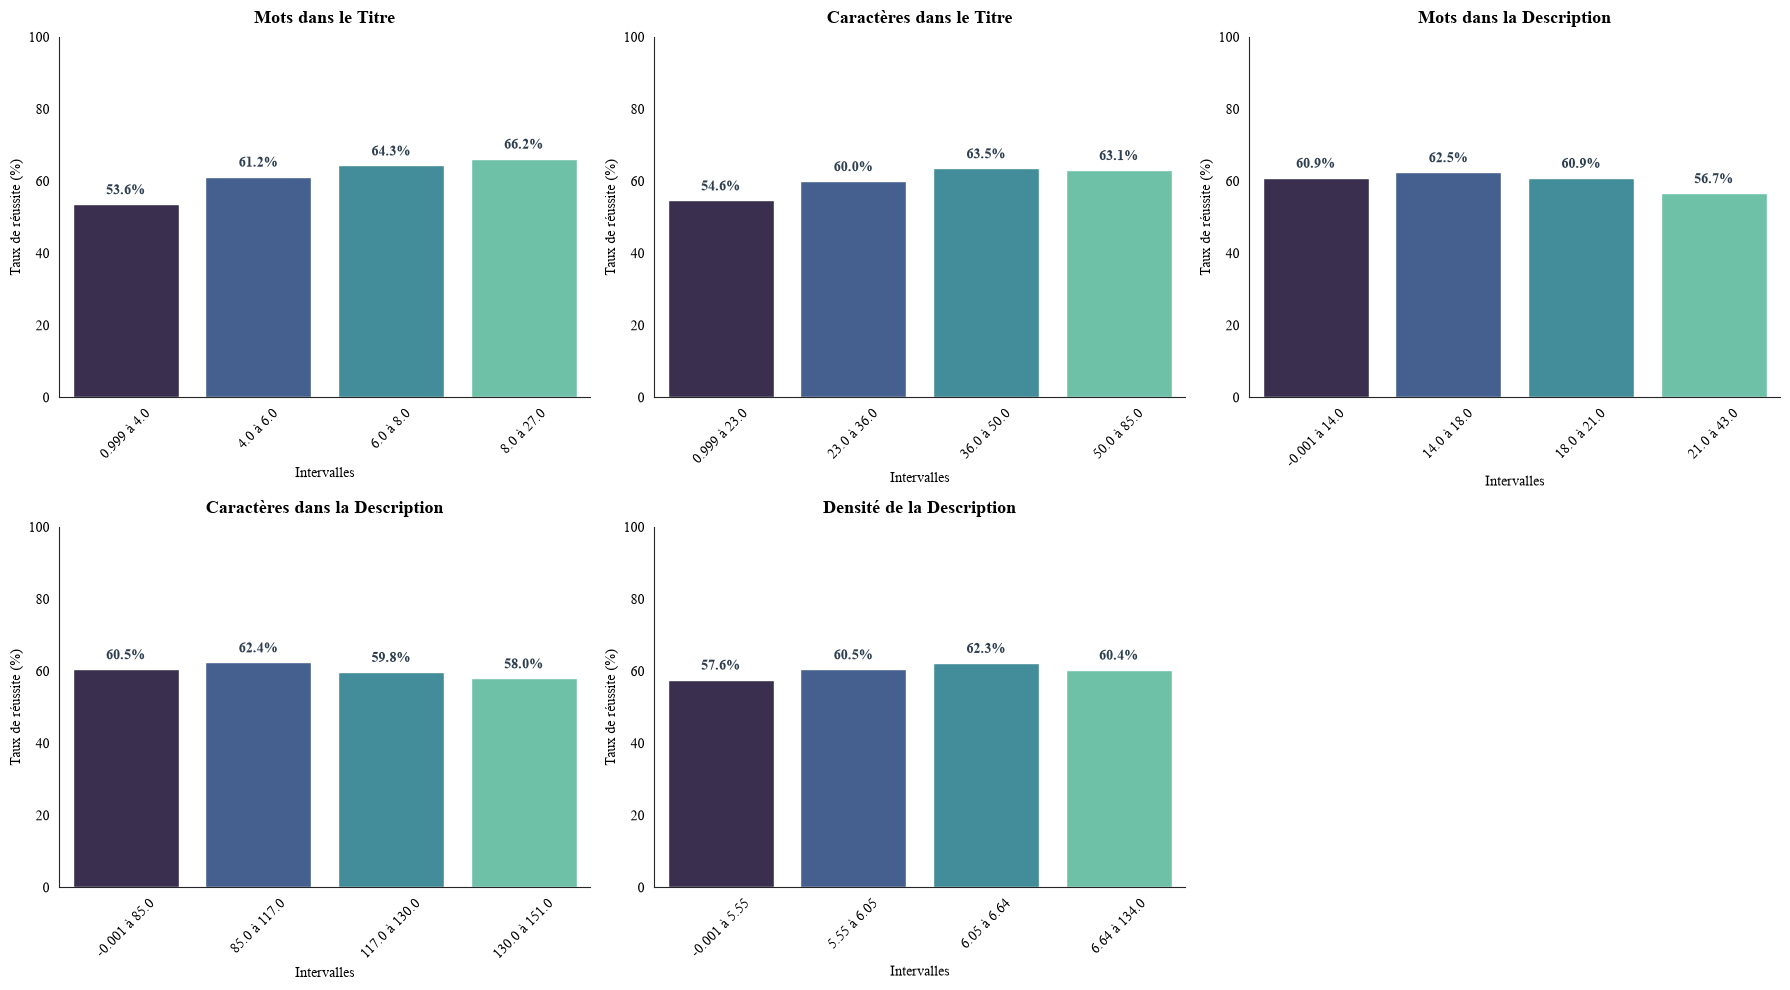

In [43]:
text_features = ['name_len_words', 'name_len_char', 'blurb_len_words', 'blurb_len_char', 'blurb_density']
titles = ['Mots dans le Titre', 'Caractères dans le Titre', 'Mots dans la Description', 'Caractères dans la Description', 'Densité de la Description']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(text_features):
    # Création de 4 tranches (quartiles) de taille égale pour chaque variable
    # duplicates='drop' évite les erreurs si beaucoup de valeurs sont identiques
    df_completed[f'{feature}_bins'] = pd.qcut(df_completed[feature], q=4, duplicates='drop')
    
    # Calcul du taux de succès par tranche
    stats = df_completed.groupby(f'{feature}_bins', observed=True).agg(
        success_rate=('is_success', lambda x: x.mean() * 100)
    ).reset_index()
    
    # Nettoyage des étiquettes pour les rendre lisibles (Ex: "(10.0, 25.0]" devient "10 à 25")
    stats['label'] = stats[f'{feature}_bins'].astype(str).str.replace('(', '', regex=False)\
                                                         .str.replace(']', '', regex=False)\
                                                         .str.replace(', ', ' à ', regex=False)
    
    # Création du barplot
    sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
    
    # Personnalisation de chaque sous-graphique
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Intervalles", fontsize=10)
    axes[i].set_ylabel("Taux de réussite (%)", fontsize=10)
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Ajout des pourcentages sur les barres
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                     fontsize=10, fontweight='bold', color='#2c3e50')

# 5. On masque le 6ème graphique vide (puisqu'on a 5 variables pour 6 cases)
axes[5].axis('off')

sns.despine()
plt.tight_layout()
plt.show()

* Pour le titre, plus c'est long, plus c'est bon. On note un escalier sur la longueur des mots et des caractères. Le titre doit être descriptif, pas mystérieux. Il doit montrer la proposition de valeur.
* Pour le blurb, il faut viser entre 14 à 18 mots pour maximiser ses chances. Si le texte est trop minimaliste, il manque d'arguments. Mais si il est trop verbeux, l'attention chute.
* Quant à la densité de la description qui reflète la taille moyenne des mots utilisés, elle montre qu'il faut privilégier un vocabulaire professionnel et précis, mais pas trop jargonneux non plus.

**Pour résumer, le signal idéal combine un titre très descriptif pour attirer le clic et un résumé percutant et concis pour convertir rapidement.**

## Conclusion

### Apprentissages

### Recommandations stratégiques